In [96]:
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

ROOT = "../compare_oct_cp0_rnd_v_exp4_train_sets"
sum_path = os.path.join(ROOT, "tree_inspection_summary.csv")
df = pd.read_csv(sum_path)

# Identify metrics columns your script wrote
metrics = ["auc","pr_auc","best_mcc","balanced_recall_gmean","balanced_specificity_gmean","optimal_f1"]
# Build paired deltas: pruned - unpruned for each dataset/seed
for m in metrics:
    df[f"delta_{m}"] = df[f"pr_{m}"] - df[f"un_{m}"]

df[["tag","seed"] + [f"un_{m}" for m in metrics] + [f"pr_{m}" for m in metrics] + [f"delta_{m}" for m in metrics]]

,tag,seed,un_auc,un_pr_auc,un_best_mcc,un_balanced_recall_gmean,un_balanced_specificity_gmean,un_optimal_f1,pr_auc,pr_pr_auc,pr_best_mcc,pr_balanced_recall_gmean,pr_balanced_specificity_gmean,pr_optimal_f1,delta_auc,delta_pr_auc,delta_best_mcc,delta_balanced_recall_gmean,delta_balanced_specificity_gmean,delta_optimal_f1
0,exp3_mix,1,0.446462,0.026695,0.065841,0.327231,0.634616,0.077253,0.525776,0.033973,0.060384,0.533181,0.476380,0.072631,0.079314,0.007278,-0.005457,0.20595,-0.158237,-0.004622
1,exp4_matched_plus_random,1,0.741120,0.053492,0.125421,0.649886,0.733384,0.115029,0.741120,0.053492,0.125421,0.649886,0.733384,0.115029,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
2,exp3_mix,2,0.505108,0.022467,0.043731,0.443936,0.612282,0.062956,0.505108,0.022467,0.043731,0.443936,0.612282,0.062956,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,exp4_matched_plus_random,2,0.734654,0.068877,0.153634,0.672769,0.686865,0.147675,0.734654,0.068877,0.153634,0.672769,0.686865,0.147675,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,exp3_mix,3,0.448338,0.019852,0.017190,0.540046,0.401254,0.054839,0.448338,0.019852,0.017190,0.540046,0.401254,0.054839,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
5,exp4_matched_plus_random,3,0.735181,0.057670,0.131368,0.695652,0.668411,0.121938,0.735181,0.057670,0.131368,0.695652,0.668411,0.121938,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
6,exp3_mix,4,0.502951,0.028313,0.062507,0.574371,0.470018,0.078382,0.502951,0.028313,0.062507,0.574371,0.470018,0.078382,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
7,exp4_matched_plus_random,4,0.732605,0.071883,0.150703,0.665904,0.737445,0.145504,0.732605,0.071883,0.150703,0.665904,0.737445,0.145504,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [97]:
#Plot: Exp3 vs Exp4 for the same pruning setting
wide = df.pivot(index="seed", columns="tag", values=[f"un_pr_auc", f"pr_pr_auc"])
# Flatten
wide.columns = [f"{a}_{b}" for a,b in wide.columns]
wide = wide.reset_index()

wide["delta_un_pr_auc_exp4_minus_exp3"] = wide["un_pr_auc_exp4_matched_plus_random"] - wide["un_pr_auc_exp3_mix"]
wide["delta_pr_pr_auc_exp4_minus_exp3"] = wide["pr_pr_auc_exp4_matched_plus_random"] - wide["pr_pr_auc_exp3_mix"]

wide[["seed","delta_un_pr_auc_exp4_minus_exp3","delta_pr_pr_auc_exp4_minus_exp3"]]

,seed,delta_un_pr_auc_exp4_minus_exp3,delta_pr_pr_auc_exp4_minus_exp3
0,1,0.026797,0.019519
1,2,0.046410,0.046410
2,3,0.037819,0.037819
3,4,0.043570,0.043570


In [98]:
#2) Leaf composition: visualize how pruning changes leaf purity/size
#Helper to load leaf files for all seeds/tags
import re

def load_leaf_files(root, tag, seed, split="train", variant="unpruned"):
    path = os.path.join(root, f"{tag}_s{seed}", f"leaf_{split}_{variant}.csv")
    df = pd.read_csv(path)
    df["tag"] = tag
    df["seed"] = seed
    df["split"] = split
    df["variant"] = variant
    return df

tags = df["tag"].unique().tolist()
seeds = sorted(df["seed"].unique())

leaf_all = []
for tag in tags:
    for s in seeds:
        for split in ["train","test"]:
            for variant in ["unpruned","pruned"]:
                leaf_all.append(load_leaf_files(ROOT, tag, s, split=split, variant=variant))
leaf_all = pd.concat(leaf_all, ignore_index=True)
leaf_all.head()

,leaf_id,n,n_pos,pos_rate,tag,seed,split,variant
0,42,8,8,1.000,exp3_mix,1,train,unpruned
1,71,7,7,1.000,exp3_mix,1,train,unpruned
2,117,10,9,0.900,exp3_mix,1,train,unpruned
3,155,10,9,0.900,exp3_mix,1,train,unpruned
4,139,24,21,0.875,exp3_mix,1,train,unpruned


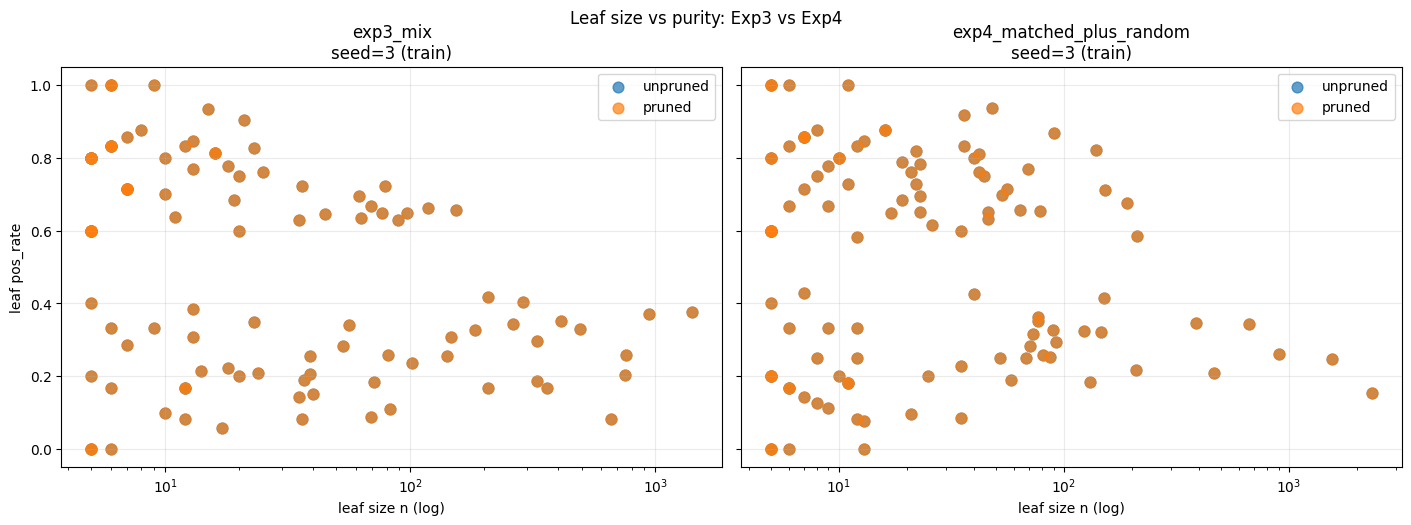

In [99]:
# Side-by-side leaf size vs purity plots for Exp3 and Exp4
import matplotlib.pyplot as plt

seed = 3
split = "train"
tags = ["exp3_mix", "exp4_matched_plus_random"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True, sharey=True)

for ax, tag in zip(axes, tags):
    a = leaf_all[
        (leaf_all.tag == tag)
        & (leaf_all.seed == seed)
        & (leaf_all.split == split)
        & (leaf_all.variant == "unpruned")
    ]
    b = leaf_all[
        (leaf_all.tag == tag)
        & (leaf_all.seed == seed)
        & (leaf_all.split == split)
        & (leaf_all.variant == "pruned")
    ]

    ax.scatter(a["n"], a["pos_rate"], s=60, alpha=0.7, label="unpruned")
    ax.scatter(b["n"], b["pos_rate"], s=60, alpha=0.7, label="pruned")
    ax.set_xscale("log")
    ax.set_xlabel("leaf size n (log)")
    ax.set_title(f"{tag}\nseed={seed} ({split})")
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[0].set_ylabel("leaf pos_rate")
fig.suptitle("Leaf size vs purity: Exp3 vs Exp4", y=1.02)
plt.show()

### Splits: what got pruned vs retained (frequency table)

In [25]:
from pathlib import Path

BASE = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_rnd_v_exp4")

all_split_files = sorted(BASE.rglob("*_splits.csv"))


In [26]:
import re
import numpy as np
import pandas as pd
from pathlib import Path

BASE = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_rnd_v_exp4")

def parse_metadata_from_path(path: Path):
    s = path.as_posix()
    name = path.name.lower()
    
    # tag
    if "exp3_mix" in s.lower():
        tag = "exp3_mix"
    elif "exp4" in s.lower():
        tag = "exp4"
    else:
        tag = "unknown"
    
    # seed from folder/file name like exp3_mix_s2
    m_seed = re.search(r"_s(\d+)", s)
    seed = int(m_seed.group(1)) if m_seed else None
    
    # variant from filename
    if "unpruned" in name:
        variant = "unpruned"
    elif "pruned" in name:
        variant = "pruned"
    else:
        variant = "unknown"
    
    # cp from filename
    m_cp = re.search(r"_cp([0-9.]+)", name)
    cp = float(m_cp.group(1)) if m_cp else np.nan
    
    return tag, seed, variant, cp

all_split_files = sorted(BASE.rglob("*_splits.csv"))

meta_rows = []
for p in all_split_files:
    tag, seed, variant, cp = parse_metadata_from_path(p)
    meta_rows.append({
        "file": str(p),
        "tag": tag,
        "seed": seed,
        "variant": variant,
        "cp": cp,
        "name": p.name,
    })

files_df = pd.DataFrame(meta_rows)
display(files_df.sort_values(["tag", "seed", "variant", "cp"]).head(50))
print("Total files:", len(files_df))

,file,tag,seed,variant,cp,name
0,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,1,pruned,0.001,oct_tree_exp3_mix_s1_pruned_d7_mb5_cp0.001_spl...
1,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,1,unpruned,0.000,oct_tree_exp3_mix_s1_unpruned_d7_mb5_cp0.0_spl...
2,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,2,pruned,0.001,oct_tree_exp3_mix_s2_pruned_d7_mb5_cp0.001_spl...
3,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,2,unpruned,0.000,oct_tree_exp3_mix_s2_unpruned_d7_mb5_cp0.0_spl...
4,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,3,pruned,0.001,oct_tree_exp3_mix_s3_pruned_d7_mb5_cp0.001_spl...
5,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,3,unpruned,0.000,oct_tree_exp3_mix_s3_unpruned_d7_mb5_cp0.0_spl...
6,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,5,pruned,0.001,oct_tree_exp3_mix_s5_pruned_d7_mb5_cp0.001_spl...
7,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,5,unpruned,0.000,oct_tree_exp3_mix_s5_unpruned_d7_mb5_cp0.0_spl...
8,/Users/cat2510/my_projects/msk_analysis/compar...,exp4,1,pruned,0.001,oct_tree_exp4_matched_plus_random_s1_pruned_d7...
9,/Users/cat2510/my_projects/msk_analysis/compar...,exp4,1,unpruned,0.000,oct_tree_exp4_matched_plus_random_s1_unpruned_...


Total files: 16


In [27]:
target_files = files_df[files_df["variant"] == "pruned"].copy()

# keep only exp3 and exp4 tags
target_files = target_files[target_files["tag"].isin(["exp3_mix", "exp4"])].copy()

display(target_files.sort_values(["tag", "seed", "cp"]))
print("n files:", len(target_files))
"""
target_cp = 0.001

target_files = files_df[
    (files_df["variant"] == "pruned") &
    (files_df["tag"].isin(["exp3_mix", "exp4"])) &
    (np.isclose(files_df["cp"], target_cp))
].copy()

display(target_files.sort_values(["tag", "seed"]))
print("n files:", len(target_files))"""

,file,tag,seed,variant,cp,name
0,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,1,pruned,0.001,oct_tree_exp3_mix_s1_pruned_d7_mb5_cp0.001_spl...
2,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,2,pruned,0.001,oct_tree_exp3_mix_s2_pruned_d7_mb5_cp0.001_spl...
4,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,3,pruned,0.001,oct_tree_exp3_mix_s3_pruned_d7_mb5_cp0.001_spl...
6,/Users/cat2510/my_projects/msk_analysis/compar...,exp3_mix,5,pruned,0.001,oct_tree_exp3_mix_s5_pruned_d7_mb5_cp0.001_spl...
8,/Users/cat2510/my_projects/msk_analysis/compar...,exp4,1,pruned,0.001,oct_tree_exp4_matched_plus_random_s1_pruned_d7...
10,/Users/cat2510/my_projects/msk_analysis/compar...,exp4,2,pruned,0.001,oct_tree_exp4_matched_plus_random_s2_pruned_d7...
12,/Users/cat2510/my_projects/msk_analysis/compar...,exp4,3,pruned,0.001,oct_tree_exp4_matched_plus_random_s3_pruned_d7...
14,/Users/cat2510/my_projects/msk_analysis/compar...,exp4,5,pruned,0.001,oct_tree_exp4_matched_plus_random_s5_pruned_d7...


n files: 8


'\ntarget_cp = 0.001\n\ntarget_files = files_df[\n    (files_df["variant"] == "pruned") &\n    (files_df["tag"].isin(["exp3_mix", "exp4"])) &\n    (np.isclose(files_df["cp"], target_cp))\n].copy()\n\ndisplay(target_files.sort_values(["tag", "seed"]))\nprint("n files:", len(target_files))'

In [28]:
def standardize_split_df(df: pd.DataFrame, meta_row: pd.Series) -> pd.DataFrame:
    out = df.copy()
    out.columns = [c.strip().lower() for c in out.columns]

    feature_col = next((c for c in ["feature", "split_feature", "variable", "var", "column"] if c in out.columns), None)
    node_col = next((c for c in ["node_id", "node", "id"] if c in out.columns), None)
    thr_col = next((c for c in ["threshold", "split_value", "cutoff", "value"] if c in out.columns), None)

    if feature_col is None or node_col is None:
        raise ValueError(f"Missing feature/node columns in {meta_row['file']}. Columns: {list(out.columns)}")

    out = out.rename(columns={
        feature_col: "feature",
        node_col: "node_id",
        **({thr_col: "threshold"} if thr_col is not None else {})
    })

    if "threshold" not in out.columns:
        out["threshold"] = np.nan

    out["feature"] = out["feature"].astype(str).str.strip()
    out["node_id_num"] = pd.to_numeric(out["node_id"], errors="coerce")

    out["tag"] = meta_row["tag"]
    out["seed"] = meta_row["seed"]
    out["variant"] = meta_row["variant"]
    out["cp"] = meta_row["cp"]
    out["file"] = meta_row["file"]

    return out[["tag", "seed", "variant", "cp", "feature", "node_id", "node_id_num", "threshold", "file"]]

loaded = []
for _, row in target_files.iterrows():
    df = pd.read_csv(row["file"])
    loaded.append(standardize_split_df(df, row))

splits_all = pd.concat(loaded, ignore_index=True)

display(
    splits_all.groupby(["seed", "tag"], as_index=False)
    .agg(
        n_splits=("feature", "size"),
        n_features=("feature", "nunique"),
        file=("file", "first"),
    )
    .sort_values(["seed", "tag"])
)

,seed,tag,n_splits,n_features,file
0,1,exp3_mix,43,29,/Users/cat2510/my_projects/msk_analysis/compar...
1,1,exp4,52,26,/Users/cat2510/my_projects/msk_analysis/compar...
2,2,exp3_mix,42,26,/Users/cat2510/my_projects/msk_analysis/compar...
3,2,exp4,52,31,/Users/cat2510/my_projects/msk_analysis/compar...
4,3,exp3_mix,42,25,/Users/cat2510/my_projects/msk_analysis/compar...
5,3,exp4,49,26,/Users/cat2510/my_projects/msk_analysis/compar...
6,5,exp3_mix,38,27,/Users/cat2510/my_projects/msk_analysis/compar...
7,5,exp4,59,34,/Users/cat2510/my_projects/msk_analysis/compar...


In [29]:
feature_inventory = (
    splits_all.groupby(["seed", "tag", "feature"], as_index=False)
    .agg(
        count_splits=("feature", "size"),
        n_unique_thresholds=("threshold", lambda x: x.nunique(dropna=True)),
        mean_threshold=("threshold", "mean"),
        median_threshold=("threshold", "median"),
        min_node_id=("node_id_num", "min"),
    )
)

display(feature_inventory.head(20))

,seed,tag,feature,count_splits,n_unique_thresholds,mean_threshold,median_threshold,min_node_id
0,1,exp3_mix,2017Q1_msk_procedure_cost_3month,2,2,-0.199769,-0.199769,4
1,1,exp3_mix,2017Q2_direct_msk_cost_3month,3,3,-0.233570,-0.235655,2
2,1,exp3_mix,2017Q2_msk_procedure_cost_3month,3,3,-0.273719,-0.302177,5
3,1,exp3_mix,2017Q3_direct_msk_cost_3month,1,1,-0.062976,-0.062976,23
4,1,exp3_mix,2017Q3_msk_procedure_cost_3month,1,1,6.163791,6.163791,65
5,1,exp3_mix,2017Q4_msk_procedure_cost_3month,1,1,-0.217114,-0.217114,20
6,1,exp3_mix,REGION_2,1,1,0.500000,0.500000,10
7,1,exp3_mix,SEX_2,1,1,0.500000,0.500000,72
8,1,exp3_mix,comorbidity_only_quarterly_cv_2017,1,1,0.609093,0.609093,1
9,1,exp3_mix,direct_msk_avg_quarterly_derivative_2017,1,1,-0.049686,-0.049686,82


In [30]:
# DIFF TABLE BETWEEEN FEATURES USED BY EXP 3 VS 4
exp4_tag = "exp4"   # change if needed
exp3_tag = "exp3_mix"
left = (
    feature_inventory[feature_inventory["tag"] == exp3_tag]
    .drop(columns="tag")
    .rename(columns={
        "count_splits": "exp3_count",
        "n_unique_thresholds": "exp3_nthr",
        "mean_threshold": "exp3_mean_thr",
        "median_threshold": "exp3_med_thr",
        "min_node_id": "exp3_min_node_id",
    })
)

right = (
    feature_inventory[feature_inventory["tag"] == exp4_tag]
    .drop(columns="tag")
    .rename(columns={
        "count_splits": "exp4_count",
        "n_unique_thresholds": "exp4_nthr",
        "mean_threshold": "exp4_mean_thr",
        "median_threshold": "exp4_med_thr",
        "min_node_id": "exp4_min_node_id",
    })
)

feature_diff = left.merge(right, on=["seed", "feature"], how="outer")

for c in ["exp3_count", "exp3_nthr", "exp4_count", "exp4_nthr"]:
    feature_diff[c] = feature_diff[c].fillna(0).astype(int)

feature_diff["count_diff_exp4_minus_exp3"] = feature_diff["exp4_count"] - feature_diff["exp3_count"]
feature_diff["abs_count_diff"] = feature_diff["count_diff_exp4_minus_exp3"].abs()

for s in sorted(feature_diff["seed"].dropna().unique()):
    print(f"\n===== Top feature differences for Seed {int(s)} =====")
    display(
        feature_diff[feature_diff["seed"] == s]
        .sort_values(["abs_count_diff", "feature"], ascending=[False, True])
        .head(10)[[
            "feature",
            "exp3_count", "exp4_count", "count_diff_exp4_minus_exp3",
            "exp3_nthr", "exp4_nthr",
            "exp3_med_thr", "exp4_med_thr",
            "exp3_min_node_id", "exp4_min_node_id",
        ]]
    )


===== Top feature differences for Seed 1 =====


,feature,exp3_count,exp4_count,count_diff_exp4_minus_exp3,exp3_nthr,exp4_nthr,exp3_med_thr,exp4_med_thr,exp3_min_node_id,exp4_min_node_id
29,msk_procedure_cost_annual,1,4,3,1,4,2.122793,-0.436678,79.0,29.0
31,msk_procedure_cost_deriv_Q2_Q3_2017,1,4,3,1,4,0.049460,0.347083,21.0,18.0
35,msk_procedure_quarterly_min_2017,2,5,3,2,5,1.435031,0.496193,52.0,3.0
1,2017Q1_msk_procedure_cost_3month,2,4,2,2,4,-0.199769,0.256883,4.0,25.0
2,2017Q2_direct_msk_cost_3month,3,1,-2,3,1,-0.235655,-0.214358,2.0,20.0
3,2017Q2_msk_procedure_cost_3month,3,1,-2,3,1,-0.302177,-0.312982,5.0,13.0
5,2017Q3_msk_procedure_cost_3month,1,3,2,1,3,6.163791,-0.146208,65.0,60.0
7,2017Q4_direct_msk_cost_3month,0,2,2,0,2,NaN,-0.224262,NaN,10.0
15,direct_msk_cost_deriv_Q1_Q2_2017,2,0,-2,2,0,0.117258,NaN,43.0,NaN
18,direct_msk_quarterly_kurtosis_2017,2,0,-2,2,0,-1.510252,NaN,30.0,NaN



===== Top feature differences for Seed 2 =====


,feature,exp3_count,exp4_count,count_diff_exp4_minus_exp3,exp3_nthr,exp4_nthr,exp3_med_thr,exp4_med_thr,exp3_min_node_id,exp4_min_node_id
46,2017Q4_msk_procedure_cost_3month,1,5,4,1,5,-0.075483,-0.053192,74.0,2.0
80,msk_procedure_quarterly_std_2017,0,4,4,0,4,NaN,0.100259,NaN,24.0
63,has_Anemia,0,3,3,0,1,NaN,0.500000,NaN,3.0
39,2017Q1_direct_msk_cost_3month,0,2,2,0,2,NaN,0.354454,NaN,14.0
43,2017Q3_direct_msk_cost_3month,0,2,2,0,2,NaN,0.446560,NaN,60.0
44,2017Q3_msk_procedure_cost_3month,3,1,-2,3,1,0.002288,-0.147116,4.0,22.0
54,direct_msk_cost_annual,0,2,2,0,2,NaN,2.218065,NaN,47.0
60,direct_msk_quarterly_min_2017,3,1,-2,3,1,4.924827,1.565644,7.0,48.0
71,msk_procedure_cost_deriv_Q1_Q2_2017,2,0,-2,2,0,-0.393581,NaN,45.0,NaN
72,msk_procedure_cost_deriv_Q3_Q4_2017,2,0,-2,2,0,-0.053938,NaN,2.0,NaN



===== Top feature differences for Seed 3 =====


,feature,exp3_count,exp4_count,count_diff_exp4_minus_exp3,exp3_nthr,exp4_nthr,exp3_med_thr,exp4_med_thr,exp3_min_node_id,exp4_min_node_id
92,direct_msk_cost_annual,2,6,4,2,6,0.368613,1.733536,4.0,4.0
93,direct_msk_cost_deriv_Q1_Q2_2017,0,3,3,0,3,NaN,0.274309,NaN,16.0
82,2017Q2_direct_msk_cost_3month,1,3,2,1,3,1.900501,-0.221295,62.0,51.0
86,2017Q4_comorbidity_only_cost_3month,0,2,2,0,2,NaN,4.466549,NaN,6.0
87,2017Q4_direct_msk_cost_3month,2,0,-2,2,0,-0.256977,NaN,48.0,NaN
97,direct_msk_quarterly_min_2017,4,2,-2,4,2,3.541238,1.017302,36.0,5.0
99,has_Anemia,0,2,2,0,1,NaN,0.500000,NaN,19.0
108,msk_procedure_cost_deriv_Q1_Q2_2017,3,1,-2,3,1,-0.053363,-0.032692,6.0,54.0
109,msk_procedure_cost_deriv_Q2_Q3_2017,3,1,-2,3,1,0.066602,0.035405,42.0,31.0
110,msk_procedure_cost_deriv_Q3_Q4_2017,2,0,-2,2,0,-0.040763,NaN,33.0,NaN



===== Top feature differences for Seed 5 =====


,feature,exp3_count,exp4_count,count_diff_exp4_minus_exp3,exp3_nthr,exp4_nthr,exp3_med_thr,exp4_med_thr,exp3_min_node_id,exp4_min_node_id
122,2017Q3_msk_procedure_cost_3month,1,5,4,1,5,0.663740,0.611733,71.0,2.0
123,2017Q4_msk_procedure_cost_3month,2,4,2,2,4,-0.197291,-0.051562,3.0,21.0
128,comorbidity_only_quarterly_cv_2017,2,0,-2,2,0,0.671418,NaN,1.0,NaN
130,direct_msk_cost_annual,1,3,2,1,3,0.126558,2.838430,46.0,5.0
148,msk_procedure_cost_deriv_Q2_Q3_2017,1,3,2,1,3,0.054406,-0.097606,16.0,20.0
153,msk_procedure_quarterly_min_2017,2,4,2,2,4,1.256572,0.180521,62.0,4.0
154,msk_procedure_quarterly_range_2017,1,3,2,1,3,-0.379933,-0.434084,42.0,73.0
119,2017Q2_direct_msk_cost_3month,1,2,1,1,2,-0.254195,0.078966,2.0,45.0
120,2017Q2_msk_procedure_cost_3month,2,3,1,2,3,2.151595,-0.221046,52.0,13.0
121,2017Q3_direct_msk_cost_3month,1,0,-1,1,0,-0.279085,NaN,30.0,NaN


In [31]:
#6) Compute overlap / uniqueness per seed
rows = []
for s in sorted(splits_all["seed"].dropna().unique()):
    f3 = set(splits_all[(splits_all["seed"] == s) & (splits_all["tag"] == exp3_tag)]["feature"])
    f4 = set(splits_all[(splits_all["seed"] == s) & (splits_all["tag"] == exp4_tag)]["feature"])

    inter = f3 & f4
    union = f3 | f4
    rows.append({
        "seed": int(s),
        "n_features_exp3": len(f3),
        "n_features_exp4": len(f4),
        "n_shared": len(inter),
        "n_exp3_only": len(f3 - f4),
        "n_exp4_only": len(f4 - f3),
        "jaccard": len(inter) / len(union) if len(union) else np.nan,
    })

overlap_df = pd.DataFrame(rows)
display(overlap_df)

,seed,n_features_exp3,n_features_exp4,n_shared,n_exp3_only,n_exp4_only,jaccard
0,1,29,26,16,13,10,0.410256
1,2,26,31,15,11,16,0.357143
2,3,25,26,15,10,11,0.416667
3,5,27,34,21,6,13,0.525000


In [32]:
#This is how you tell whether differences are robust across seeds.
# This will show whether any feature consistently appears more often in Exp4 or Exp3.
stability = (
    feature_diff.groupby("feature", as_index=False)
    .agg(
        seeds_with_exp3=("exp3_count", lambda x: int((x > 0).sum())),
        seeds_with_exp4=("exp4_count", lambda x: int((x > 0).sum())),
        mean_diff=("count_diff_exp4_minus_exp3", "mean"),
        median_diff=("count_diff_exp4_minus_exp3", "median"),
        exp4_more_often=("count_diff_exp4_minus_exp3", lambda x: int((x > 0).sum())),
        exp3_more_often=("count_diff_exp4_minus_exp3", lambda x: int((x < 0).sum())),
        same_count=("count_diff_exp4_minus_exp3", lambda x: int((x == 0).sum())),
        mean_abs_diff=("abs_count_diff", "mean"),
    )
    .sort_values(["mean_abs_diff", "feature"], ascending=[False, True])
)
top_features = stability.head(15)["feature"].tolist()
stability.head(15)

,feature,seeds_with_exp3,seeds_with_exp4,mean_diff,median_diff,exp4_more_often,exp3_more_often,same_count,mean_abs_diff
46,msk_procedure_cost_deriv_Q2_Q3_2017,3,3,1.000000,2.0,2,1,0,2.333333
5,2017Q3_msk_procedure_cost_3month,3,4,1.250000,1.5,3,1,0,2.250000
20,direct_msk_cost_annual,3,4,2.250000,2.0,4,0,0,2.250000
8,2017Q4_msk_procedure_cost_3month,4,4,1.500000,1.5,3,1,0,2.000000
55,msk_procedure_quarterly_std_2017,1,3,1.500000,1.5,3,1,0,2.000000
45,msk_procedure_cost_deriv_Q1_Q2_2017,4,2,-1.750000,-2.0,0,4,0,1.750000
52,msk_procedure_quarterly_min_2017,4,4,0.750000,0.5,2,2,0,1.750000
21,direct_msk_cost_deriv_Q1_Q2_2017,2,2,0.333333,0.0,1,1,1,1.666667
50,msk_procedure_quarterly_kurtosis_2017,2,3,1.666667,2.0,3,0,0,1.666667
2,2017Q2_direct_msk_cost_3month,4,3,0.000000,0.0,2,2,0,1.500000


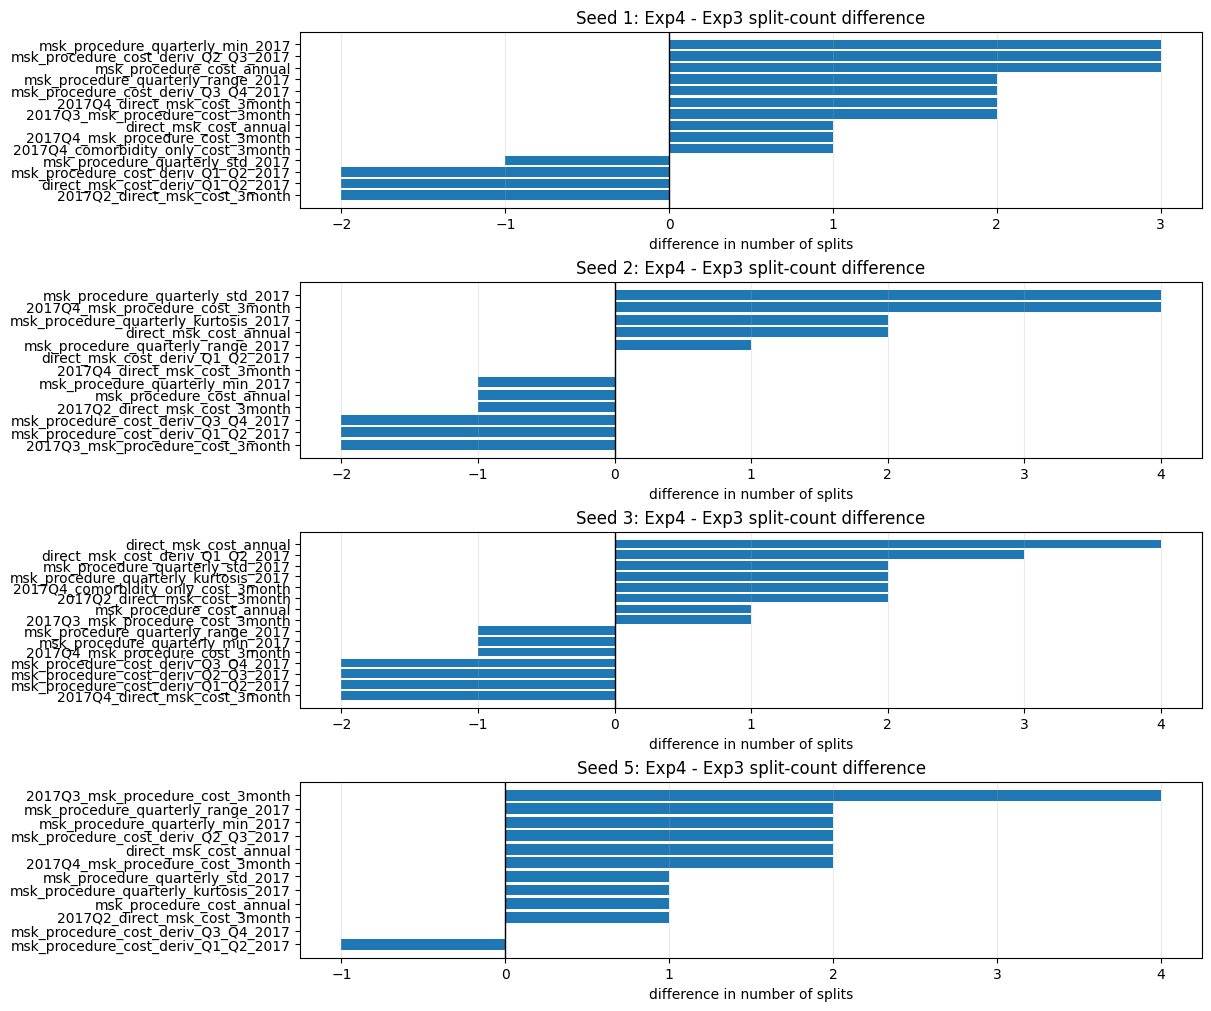

In [33]:

tmp = feature_diff[feature_diff["feature"].isin(top_features)].copy()

fig, axes = plt.subplots(len(sorted(tmp["seed"].dropna().unique())), 1,
                         figsize=(12, 2.5 * len(sorted(tmp["seed"].dropna().unique()))),
                         constrained_layout=True)

if not isinstance(axes, np.ndarray):
    axes = [axes]

for ax, s in zip(axes, sorted(tmp["seed"].dropna().unique())):
    d = tmp[tmp["seed"] == s].sort_values("count_diff_exp4_minus_exp3")
    ax.barh(d["feature"], d["count_diff_exp4_minus_exp3"])
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Seed {int(s)}: Exp4 - Exp3 split-count difference")
    ax.set_xlabel("difference in number of splits")
    ax.grid(True, axis="x", alpha=0.25)

plt.show()

### Feature family analysis 

In [34]:
# --- feature family mapping ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def feature_family(feat: str) -> str:
    f = str(feat).lower()

    # diagnosis / binary flags
    if f.startswith("has_") or f.startswith("is_") or f.endswith("_adherent"):
        return "diagnosis_flag"

    # temporal change / derivative
    if "_deriv_" in f:
        return "derivative_change"

    # dispersion / shape summaries
    if any(tok in f for tok in ["_std_", "_cv_", "_skewness_", "_kurtosis_", "_range_"]):
        return "dispersion_shape"

    # extrema summaries
    if any(tok in f for tok in ["_min_", "_max_"]):
        return "extrema"

    # annual / quarterly / 3-month level summaries
    if any(tok in f for tok in ["_3month", "_annual"]):
        return "level_summary"

    return "other"


def source_family(feat: str) -> str:
    f = str(feat).lower()

    if "procedure" in f:
        return "procedure"
    if "direct_msk" in f:
        return "direct_msk"
    if "comorbidity_only" in f:
        return "comorbidity_only"
    if f.startswith("has_") or f.startswith("is_"):
        return "diagnosis_flag"
    return "other"

In [35]:
# --- load BOTH unpruned and pruned split files ---
target_tags = ["exp3_mix", "exp4"]   # change exp4 label if needed

target_files_all = files_df[
    files_df["tag"].isin(target_tags) &
    files_df["variant"].isin(["unpruned", "pruned"])
].copy()

loaded = []
for _, row in target_files_all.iterrows():
    df = pd.read_csv(row["file"])
    tmp = standardize_split_df(df, row)
    loaded.append(tmp)

splits_master = pd.concat(loaded, ignore_index=True)

splits_master["family"] = splits_master["feature"].apply(feature_family)
splits_master["source_family"] = splits_master["feature"].apply(source_family)

display(splits_master.head())
print(splits_master.shape)

,tag,seed,variant,cp,feature,node_id,node_id_num,threshold,file,family,source_family
0,exp3_mix,1,pruned,0.001,comorbidity_only_quarterly_cv_2017,1,1,0.609093,/Users/cat2510/my_projects/msk_analysis/compar...,dispersion_shape,comorbidity_only
1,exp3_mix,1,pruned,0.001,2017Q2_direct_msk_cost_3month,2,2,-0.249254,/Users/cat2510/my_projects/msk_analysis/compar...,level_summary,direct_msk
2,exp3_mix,1,pruned,0.001,msk_procedure_quarterly_max_2017,3,3,1.092004,/Users/cat2510/my_projects/msk_analysis/compar...,extrema,procedure
3,exp3_mix,1,pruned,0.001,2017Q1_msk_procedure_cost_3month,4,4,-0.248188,/Users/cat2510/my_projects/msk_analysis/compar...,level_summary,procedure
4,exp3_mix,1,pruned,0.001,2017Q2_msk_procedure_cost_3month,5,5,-0.311602,/Users/cat2510/my_projects/msk_analysis/compar...,level_summary,procedure


(1190, 11)


In [36]:
family_counts = (
    splits_master.groupby(["tag", "variant", "seed", "family"], as_index=False)
    .agg(n_splits=("feature", "size"))
)

family_counts["share"] = (
    family_counts["n_splits"] /
    family_counts.groupby(["tag", "variant", "seed"])["n_splits"].transform("sum")
)

#display(family_counts.head(20))
family_summary = (
    family_counts.groupby(["tag", "variant", "family"], as_index=False)
    .agg(
        mean_share=("share", "mean"),
        std_share=("share", "std"),
        mean_n_splits=("n_splits", "mean"),
    )
    .sort_values(["variant", "tag", "mean_share"], ascending=[True, True, False])
)


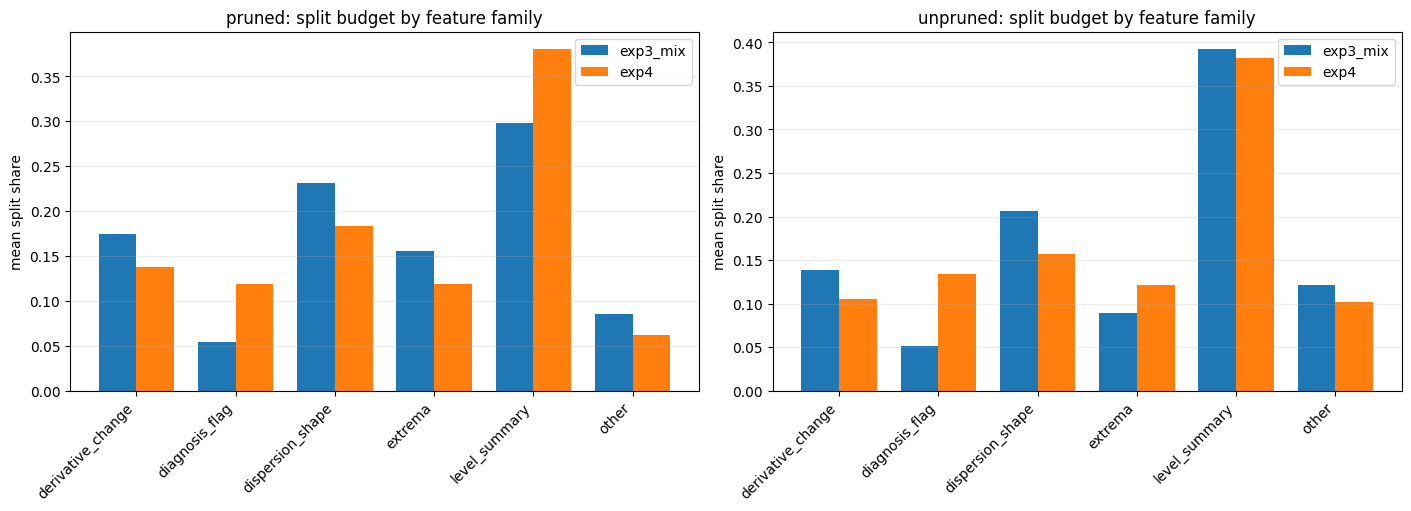

In [37]:
variants = sorted(family_summary["variant"].unique())
families = sorted(family_summary["family"].unique())

fig, axes = plt.subplots(1, len(variants), figsize=(7 * len(variants), 5), constrained_layout=True)
if len(variants) == 1:
    axes = [axes]

for ax, variant in zip(axes, variants):
    d = family_summary[family_summary["variant"] == variant].copy()

    pivot = d.pivot(index="family", columns="tag", values="mean_share").fillna(0)
    pivot = pivot.loc[sorted(pivot.index)]

    x = np.arange(len(pivot.index))
    w = 0.38

    for i, tag in enumerate(pivot.columns):
        ax.bar(x + (i - 0.5) * w, pivot[tag].values, width=w, label=tag)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")
    ax.set_ylabel("mean split share")
    ax.set_title(f"{variant}: split budget by feature family")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.25)

plt.show()

5) Feature-level prune survival

Now the second part: which features are consistently pruned vs retained.

In [38]:
feat_counts = (
    splits_master.groupby(["tag", "seed", "variant", "feature", "family", "source_family"], as_index=False)
    .agg(n_splits=("feature", "size"))
)

unpr = (
    feat_counts[feat_counts["variant"] == "unpruned"]
    .drop(columns="variant")
    .rename(columns={"n_splits": "n_unpruned"})
)

prun = (
    feat_counts[feat_counts["variant"] == "pruned"]
    .drop(columns="variant")
    .rename(columns={"n_splits": "n_pruned"})
)

prune_compare = unpr.merge(
    prun,
    on=["tag", "seed", "feature", "family", "source_family"],
    how="outer"
).fillna({"n_unpruned": 0, "n_pruned": 0})

prune_compare["n_unpruned"] = prune_compare["n_unpruned"].astype(int)
prune_compare["n_pruned"] = prune_compare["n_pruned"].astype(int)

prune_compare["n_pruned_away"] = prune_compare["n_unpruned"] - prune_compare["n_pruned"]
prune_compare["survival_rate"] = np.where(
    prune_compare["n_unpruned"] > 0,
    prune_compare["n_pruned"] / prune_compare["n_unpruned"],
    np.nan
)

display(prune_compare.head(10))

,tag,seed,feature,family,source_family,n_unpruned,n_pruned,n_pruned_away,survival_rate
0,exp3_mix,1,2017Q1_comorbidity_only_cost_3month,level_summary,comorbidity_only,1,0,1,0.00
1,exp3_mix,1,2017Q1_direct_msk_cost_3month,level_summary,direct_msk,1,0,1,0.00
2,exp3_mix,1,2017Q1_msk_procedure_cost_3month,level_summary,procedure,2,2,0,1.00
3,exp3_mix,1,2017Q2_direct_msk_cost_3month,level_summary,direct_msk,5,3,2,0.60
4,exp3_mix,1,2017Q2_msk_procedure_cost_3month,level_summary,procedure,2,3,-1,1.50
5,exp3_mix,1,2017Q3_direct_msk_cost_3month,level_summary,direct_msk,0,1,-1,NaN
6,exp3_mix,1,2017Q3_msk_procedure_cost_3month,level_summary,procedure,5,1,4,0.20
7,exp3_mix,1,2017Q4_comorbidity_only_cost_3month,level_summary,comorbidity_only,1,0,1,0.00
8,exp3_mix,1,2017Q4_direct_msk_cost_3month,level_summary,direct_msk,2,0,2,0.00
9,exp3_mix,1,2017Q4_msk_procedure_cost_3month,level_summary,procedure,4,1,3,0.25


In [39]:
prune_stability = (
    prune_compare.groupby(["tag", "feature", "family", "source_family"], as_index=False)
    .agg(
        seeds_unpruned=("n_unpruned", lambda x: int((x > 0).sum())),
        seeds_pruned_retained=("n_pruned", lambda x: int((x > 0).sum())),
        mean_unpruned=("n_unpruned", "mean"),
        mean_pruned=("n_pruned", "mean"),
        mean_survival_rate=("survival_rate", "mean"),
        median_survival_rate=("survival_rate", "median"),
        fully_pruned_in_n_seeds=("survival_rate", lambda x: int(np.nansum(x == 0))),
        fully_survived_in_n_seeds=("survival_rate", lambda x: int(np.nansum(x == 1))),
    )
)


consistently_pruned = prune_stability[
    (prune_stability["seeds_unpruned"] >= 3) &
    (prune_stability["seeds_pruned_retained"] <= 1)
].sort_values(["tag", "seeds_unpruned", "mean_survival_rate"], ascending=[True, False, True])
print("Features that consistently are pruned")

display(consistently_pruned)

Features that consistently are pruned


,tag,feature,family,source_family,seeds_unpruned,seeds_pruned_retained,mean_unpruned,mean_pruned,mean_survival_rate,median_survival_rate,fully_pruned_in_n_seeds,fully_survived_in_n_seeds
9,exp3_mix,2017Q4_comorbidity_only_cost_3month,level_summary,comorbidity_only,4,0,1.500000,0.000000,0.000000,0.0,4,0
30,exp3_mix,comorbidity_only_quarterly_std_2017,dispersion_shape,comorbidity_only,4,0,1.250000,0.000000,0.000000,0.0,4,0
46,exp3_mix,direct_msk_quarterly_std_2017,dispersion_shape,direct_msk,4,1,2.750000,0.250000,0.083333,0.0,3,0
35,exp3_mix,direct_msk_cost_deriv_Q2_Q3_2017,derivative_change,direct_msk,4,1,2.500000,0.250000,0.250000,0.0,3,1
71,exp3_mix,msk_procedure_quarterly_std_2017,dispersion_shape,procedure,4,1,3.000000,0.250000,0.250000,0.0,3,1
1,exp3_mix,2017Q1_direct_msk_cost_3month,level_summary,direct_msk,4,1,1.500000,0.500000,0.500000,0.0,3,0
0,exp3_mix,2017Q1_comorbidity_only_cost_3month,level_summary,comorbidity_only,3,0,1.333333,0.000000,0.000000,0.0,3,0
21,exp3_mix,comorbidity_only_cost_annual,level_summary,comorbidity_only,3,0,2.666667,0.000000,0.000000,0.0,3,0
44,exp3_mix,direct_msk_quarterly_range_2017,dispersion_shape,direct_msk,3,0,1.333333,0.000000,0.000000,0.0,3,0
112,exp4,direct_msk_quarterly_skewness_2017,dispersion_shape,direct_msk,4,1,1.750000,0.250000,0.083333,0.0,3,0


In [68]:
print("Features that consistently survived")
consistently_survived = prune_stability[
    (prune_stability["seeds_unpruned"] >= 3) &
    (prune_stability["mean_survival_rate"] >= 0.75)
].sort_values(["tag", "mean_survival_rate", "seeds_unpruned"], ascending=[True, False, False])

display(consistently_survived)

Features that consistently survived


,tag,feature,family,source_family,seeds_unpruned,seeds_pruned_retained,mean_unpruned,mean_pruned,mean_survival_rate,median_survival_rate,fully_pruned_in_n_seeds,fully_survived_in_n_seeds
65,exp3_mix,msk_procedure_quarterly_cv_2017,dispersion_shape,procedure,4,4,1.50,2.00,1.666667,2.000000,0,0
43,exp3_mix,direct_msk_quarterly_min_2017,extrema,direct_msk,4,4,2.00,2.50,1.541667,1.333333,0,0
45,exp3_mix,direct_msk_quarterly_skewness_2017,dispersion_shape,direct_msk,4,4,1.25,1.25,1.125000,1.000000,0,2
61,exp3_mix,msk_procedure_cost_deriv_Q2_Q3_2017,derivative_change,procedure,4,3,1.50,1.25,1.125000,0.750000,1,1
2,exp3_mix,2017Q1_msk_procedure_cost_3month,level_summary,procedure,4,4,2.25,1.75,0.833333,1.000000,0,3
68,exp3_mix,msk_procedure_quarterly_min_2017,extrema,procedure,4,4,4.25,2.75,0.791667,0.666667,0,0
36,exp3_mix,direct_msk_cost_deriv_Q3_Q4_2017,derivative_change,direct_msk,3,3,1.25,1.00,0.777778,0.333333,1,0
41,exp3_mix,direct_msk_quarterly_kurtosis_2017,dispersion_shape,direct_msk,4,2,1.50,1.00,0.750000,0.500000,2,1
42,exp3_mix,direct_msk_quarterly_max_2017,extrema,direct_msk,4,3,1.00,0.75,0.750000,1.000000,1,3
136,exp4,msk_procedure_quarterly_kurtosis_2017,dispersion_shape,procedure,3,3,1.25,2.00,1.333333,1.000000,1,1


In [41]:
left = (
    prune_stability[prune_stability["tag"] == "exp3_mix"]
    .drop(columns="tag")
    .rename(columns={
        "seeds_unpruned": "exp3_seeds_unpruned",
        "seeds_pruned_retained": "exp3_seeds_retained",
        "mean_unpruned": "exp3_mean_unpruned",
        "mean_pruned": "exp3_mean_pruned",
        "mean_survival_rate": "exp3_mean_survival",
        "median_survival_rate": "exp3_median_survival",
        "fully_pruned_in_n_seeds": "exp3_fully_pruned_n",
        "fully_survived_in_n_seeds": "exp3_fully_survived_n",
    })
)

right = (
    prune_stability[prune_stability["tag"] == "exp4"]
    .drop(columns="tag")
    .rename(columns={
        "seeds_unpruned": "exp4_seeds_unpruned",
        "seeds_pruned_retained": "exp4_seeds_retained",
        "mean_unpruned": "exp4_mean_unpruned",
        "mean_pruned": "exp4_mean_pruned",
        "mean_survival_rate": "exp4_mean_survival",
        "median_survival_rate": "exp4_median_survival",
        "fully_pruned_in_n_seeds": "exp4_fully_pruned_n",
        "fully_survived_in_n_seeds": "exp4_fully_survived_n",
    })
)

survival_diff = left.merge(
    right,
    on=["feature", "family", "source_family"],
    how="outer"
)

survival_diff["survival_diff_exp4_minus_exp3"] = (
    survival_diff["exp4_mean_survival"] - survival_diff["exp3_mean_survival"]
)

display(
    survival_diff.sort_values("survival_diff_exp4_minus_exp3", ascending=False).head(30)
)
display(
    survival_diff.sort_values("survival_diff_exp4_minus_exp3", ascending=True).head(30)
)

,feature,family,source_family,exp3_seeds_unpruned,exp3_seeds_retained,exp3_mean_unpruned,exp3_mean_pruned,exp3_mean_survival,exp3_median_survival,exp3_fully_pruned_n,exp3_fully_survived_n,exp4_seeds_unpruned,exp4_seeds_retained,exp4_mean_unpruned,exp4_mean_pruned,exp4_mean_survival,exp4_median_survival,exp4_fully_pruned_n,exp4_fully_survived_n,survival_diff_exp4_minus_exp3
50,direct_msk_quarterly_range_2017,dispersion_shape,direct_msk,3.0,0.0,1.333333,0.00,0.000000,0.000000,3.0,0.0,1.0,1.0,1.00,1.000000,1.000000,1.000000,0.0,1.0,1.000000
79,msk_procedure_quarterly_kurtosis_2017,dispersion_shape,procedure,3.0,2.0,2.333333,1.00,0.500000,0.500000,1.0,1.0,3.0,3.0,1.25,2.000000,1.333333,1.000000,1.0,1.0,0.833333
38,direct_msk_cost_annual,level_summary,direct_msk,4.0,3.0,4.250000,1.00,0.312500,0.291667,1.0,0.0,4.0,4.0,3.25,3.250000,1.020833,0.708333,0.0,0.0,0.708333
84,msk_procedure_quarterly_std_2017,dispersion_shape,procedure,4.0,1.0,3.000000,0.25,0.250000,0.000000,3.0,1.0,4.0,3.0,2.00,1.750000,0.958333,0.916667,1.0,0.0,0.708333
63,has_Long_term_Drug_Therapy,diagnosis_flag,diagnosis_flag,1.0,0.0,1.000000,0.00,0.000000,0.000000,1.0,0.0,3.0,2.0,1.00,0.666667,0.666667,1.000000,1.0,2.0,0.666667
39,direct_msk_cost_deriv_Q1_Q2_2017,derivative_change,direct_msk,4.0,2.0,1.750000,1.00,0.500000,0.500000,2.0,2.0,2.0,2.0,1.00,1.666667,1.000000,1.000000,1.0,0.0,0.500000
4,2017Q2_direct_msk_cost_3month,level_summary,direct_msk,4.0,4.0,3.500000,1.50,0.420833,0.416667,0.0,0.0,4.0,3.0,2.00,1.500000,0.791667,0.833333,1.0,1.0,0.370833
11,2017Q4_msk_procedure_cost_3month,level_summary,procedure,4.0,4.0,5.250000,1.75,0.385417,0.375000,0.0,0.0,4.0,4.0,4.75,3.250000,0.750595,0.733333,0.0,0.0,0.365179
57,has_Chronic_Pain,diagnosis_flag,diagnosis_flag,1.0,0.0,1.000000,0.00,0.000000,0.000000,1.0,0.0,3.0,1.0,1.00,0.333333,0.333333,0.000000,2.0,1.0,0.333333
83,msk_procedure_quarterly_skewness_2017,dispersion_shape,procedure,4.0,4.0,3.750000,1.75,0.641667,0.700000,0.0,2.0,4.0,4.0,2.50,1.500000,0.966667,0.833333,0.0,1.0,0.325000


,feature,family,source_family,exp3_seeds_unpruned,exp3_seeds_retained,exp3_mean_unpruned,exp3_mean_pruned,exp3_mean_survival,exp3_median_survival,exp3_fully_pruned_n,exp3_fully_survived_n,exp4_seeds_unpruned,exp4_seeds_retained,exp4_mean_unpruned,exp4_mean_pruned,exp4_mean_survival,exp4_median_survival,exp4_fully_pruned_n,exp4_fully_survived_n,survival_diff_exp4_minus_exp3
78,msk_procedure_quarterly_cv_2017,dispersion_shape,procedure,4.0,4.0,1.500000,2.000000,1.666667,2.000000,0.0,0.0,4.0,3.0,3.500000,1.000000,0.395833,0.291667,1.0,1.0,-1.270833
49,direct_msk_quarterly_min_2017,extrema,direct_msk,4.0,4.0,2.000000,2.500000,1.541667,1.333333,0.0,0.0,4.0,4.0,3.750000,1.500000,0.425000,0.416667,0.0,0.0,-1.116667
72,msk_procedure_cost_deriv_Q1_Q2_2017,derivative_change,procedure,2.0,4.0,1.250000,2.250000,1.250000,1.250000,0.0,0.0,3.0,2.0,3.333333,0.666667,0.166667,0.250000,1.0,0.0,-1.083333
51,direct_msk_quarterly_skewness_2017,dispersion_shape,direct_msk,4.0,4.0,1.250000,1.250000,1.125000,1.000000,0.0,2.0,4.0,1.0,1.750000,0.250000,0.083333,0.000000,3.0,0.0,-1.041667
20,REGION_2,other,other,2.0,3.0,1.000000,1.000000,0.750000,0.750000,0.0,1.0,1.0,0.0,1.000000,0.000000,0.000000,0.000000,1.0,0.0,-0.750000
62,has_Hypertension,diagnosis_flag,diagnosis_flag,1.0,1.0,1.000000,1.000000,1.000000,1.000000,0.0,1.0,3.0,1.0,1.000000,0.333333,0.333333,0.000000,2.0,1.0,-0.666667
23,SEX_2,other,other,2.0,1.0,1.500000,0.500000,0.500000,0.500000,1.0,1.0,1.0,0.0,1.000000,0.000000,0.000000,0.000000,1.0,0.0,-0.500000
48,direct_msk_quarterly_max_2017,extrema,direct_msk,4.0,3.0,1.000000,0.750000,0.750000,1.000000,1.0,3.0,3.0,1.0,1.666667,0.333333,0.333333,0.000000,2.0,1.0,-0.416667
7,2017Q3_direct_msk_cost_3month,level_summary,direct_msk,3.0,3.0,1.000000,0.750000,0.500000,0.500000,1.0,1.0,4.0,1.0,3.750000,0.500000,0.125000,0.000000,3.0,0.0,-0.375000
1,2017Q1_direct_msk_cost_3month,level_summary,direct_msk,4.0,1.0,1.500000,0.500000,0.500000,0.000000,3.0,0.0,4.0,3.0,5.500000,1.250000,0.235714,0.271429,1.0,0.0,-0.264286


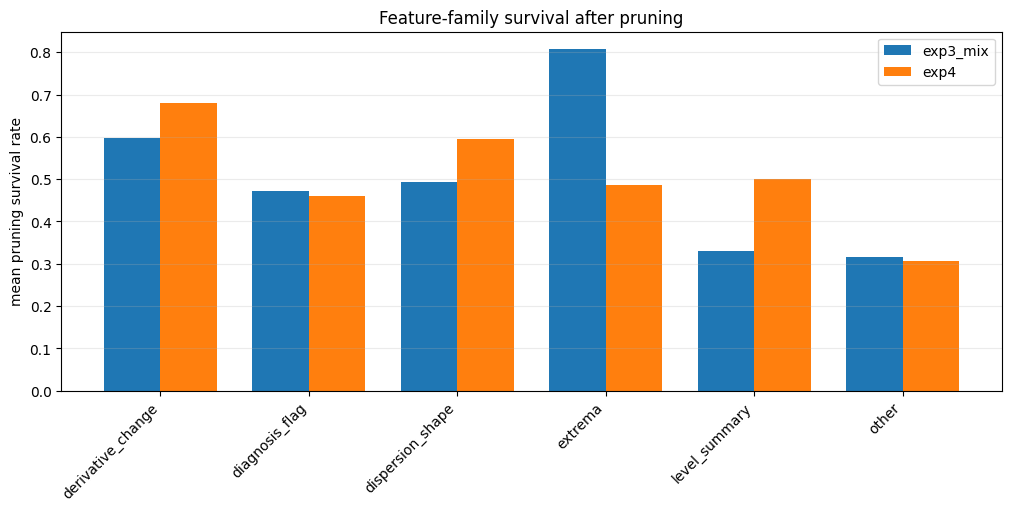

In [42]:
# Family-level prune survival
family_prune = (
    prune_compare.groupby(["tag", "seed", "family"], as_index=False)
    .agg(
        total_unpruned=("n_unpruned", "sum"),
        total_pruned=("n_pruned", "sum"),
    )
)

family_prune["survival_rate"] = np.where(
    family_prune["total_unpruned"] > 0,
    family_prune["total_pruned"] / family_prune["total_unpruned"],
    np.nan
)

family_prune_summary = (
    family_prune.groupby(["tag", "family"], as_index=False)
    .agg(
        mean_survival=("survival_rate", "mean"),
        median_survival=("survival_rate", "median"),
    )
    .sort_values(["tag", "mean_survival"], ascending=[True, False])
)

pivot = family_prune_summary.pivot(index="family", columns="tag", values="mean_survival").fillna(0)
pivot = pivot.loc[sorted(pivot.index)]

x = np.arange(len(pivot.index))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for i, tag in enumerate(pivot.columns):
    ax.bar(x + (i - 0.5) * w, pivot[tag].values, width=w, label=tag)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45, ha="right")
ax.set_ylabel("mean pruning survival rate")
ax.set_title("Feature-family survival after pruning")
ax.legend()
ax.grid(True, axis="y", alpha=0.25)
plt.show()

In [43]:
#This gives concise statements like “derivative features survive more in Exp3.”
paper_table = (
    family_prune.groupby(["tag", "family"], as_index=False)
    .agg(
        mean_survival=("survival_rate", "mean"),
        std_survival=("survival_rate", "std"),
        mean_unpruned_budget=("total_unpruned", "mean"),
        mean_pruned_budget=("total_pruned", "mean"),
    )
)

display(paper_table.sort_values(["family", "tag"]))

,tag,family,mean_survival,std_survival,mean_unpruned_budget,mean_pruned_budget
0,exp3_mix,derivative_change,0.597841,0.314674,13.50,7.25
6,exp4,derivative_change,0.681133,0.175372,11.00,7.25
1,exp3_mix,diagnosis_flag,0.471429,0.132480,5.00,2.25
7,exp4,diagnosis_flag,0.461086,0.127377,14.25,6.25
2,exp3_mix,dispersion_shape,0.493949,0.156228,20.25,9.50
8,exp4,dispersion_shape,0.594669,0.280801,16.50,9.75
3,exp3_mix,extrema,0.808333,0.397562,8.50,6.50
9,exp4,extrema,0.486364,0.149307,12.75,6.25
4,exp3_mix,level_summary,0.330743,0.089763,38.75,12.25
10,exp4,level_summary,0.500906,0.046421,40.25,20.25


### Do those “stable retained” features actually separate minority vs majority differently in the original train set, Exp3 sample, and Exp4 sample?

In [44]:
import numpy as np
import pandas as pd

# features with strong pruning-survival difference
stable_survival = survival_diff.copy()

# adjust thresholds if needed
stable_survival = stable_survival[
    (
        stable_survival[["exp3_seeds_unpruned", "exp4_seeds_unpruned"]]
        .max(axis=1) >= 3
    )
].copy()

stable_survival["abs_survival_diff"] = stable_survival["survival_diff_exp4_minus_exp3"].abs()

# optionally merge in split-count asymmetry
feat_strength = feature_diff.groupby("feature", as_index=False).agg(
    mean_abs_split_diff=("abs_count_diff", "mean")
)

stable_survival = stable_survival.merge(feat_strength, on="feature", how="left")

# combined ranking score
stable_survival["priority_score"] = (
    stable_survival["abs_survival_diff"].fillna(0)
    + 0.15 * stable_survival["mean_abs_split_diff"].fillna(0)
)

stable_survival = stable_survival.sort_values("priority_score", ascending=False)

# top features surviving more in Exp4
top_exp4 = (
    stable_survival[stable_survival["survival_diff_exp4_minus_exp3"] > 0]
    .sort_values("priority_score", ascending=False)
    .head(5)["feature"]
    .tolist()
)

# top features surviving more in Exp3
top_exp3 = (
    stable_survival[stable_survival["survival_diff_exp4_minus_exp3"] < 0]
    .sort_values("priority_score", ascending=False)
    .head(5)["feature"]
    .tolist()
)

selected_features = top_exp4 + top_exp3
selected_features

['direct_msk_quarterly_range_2017',
 'msk_procedure_quarterly_kurtosis_2017',
 'direct_msk_cost_annual',
 'msk_procedure_quarterly_std_2017',
 'has_Long_term_Drug_Therapy',
 'msk_procedure_quarterly_cv_2017',
 'msk_procedure_cost_deriv_Q1_Q2_2017',
 'direct_msk_quarterly_min_2017',
 'direct_msk_quarterly_skewness_2017',
 'has_Hypertension']

(251110, 99) (10188, 99) (10188, 99)
Missing selected features: []


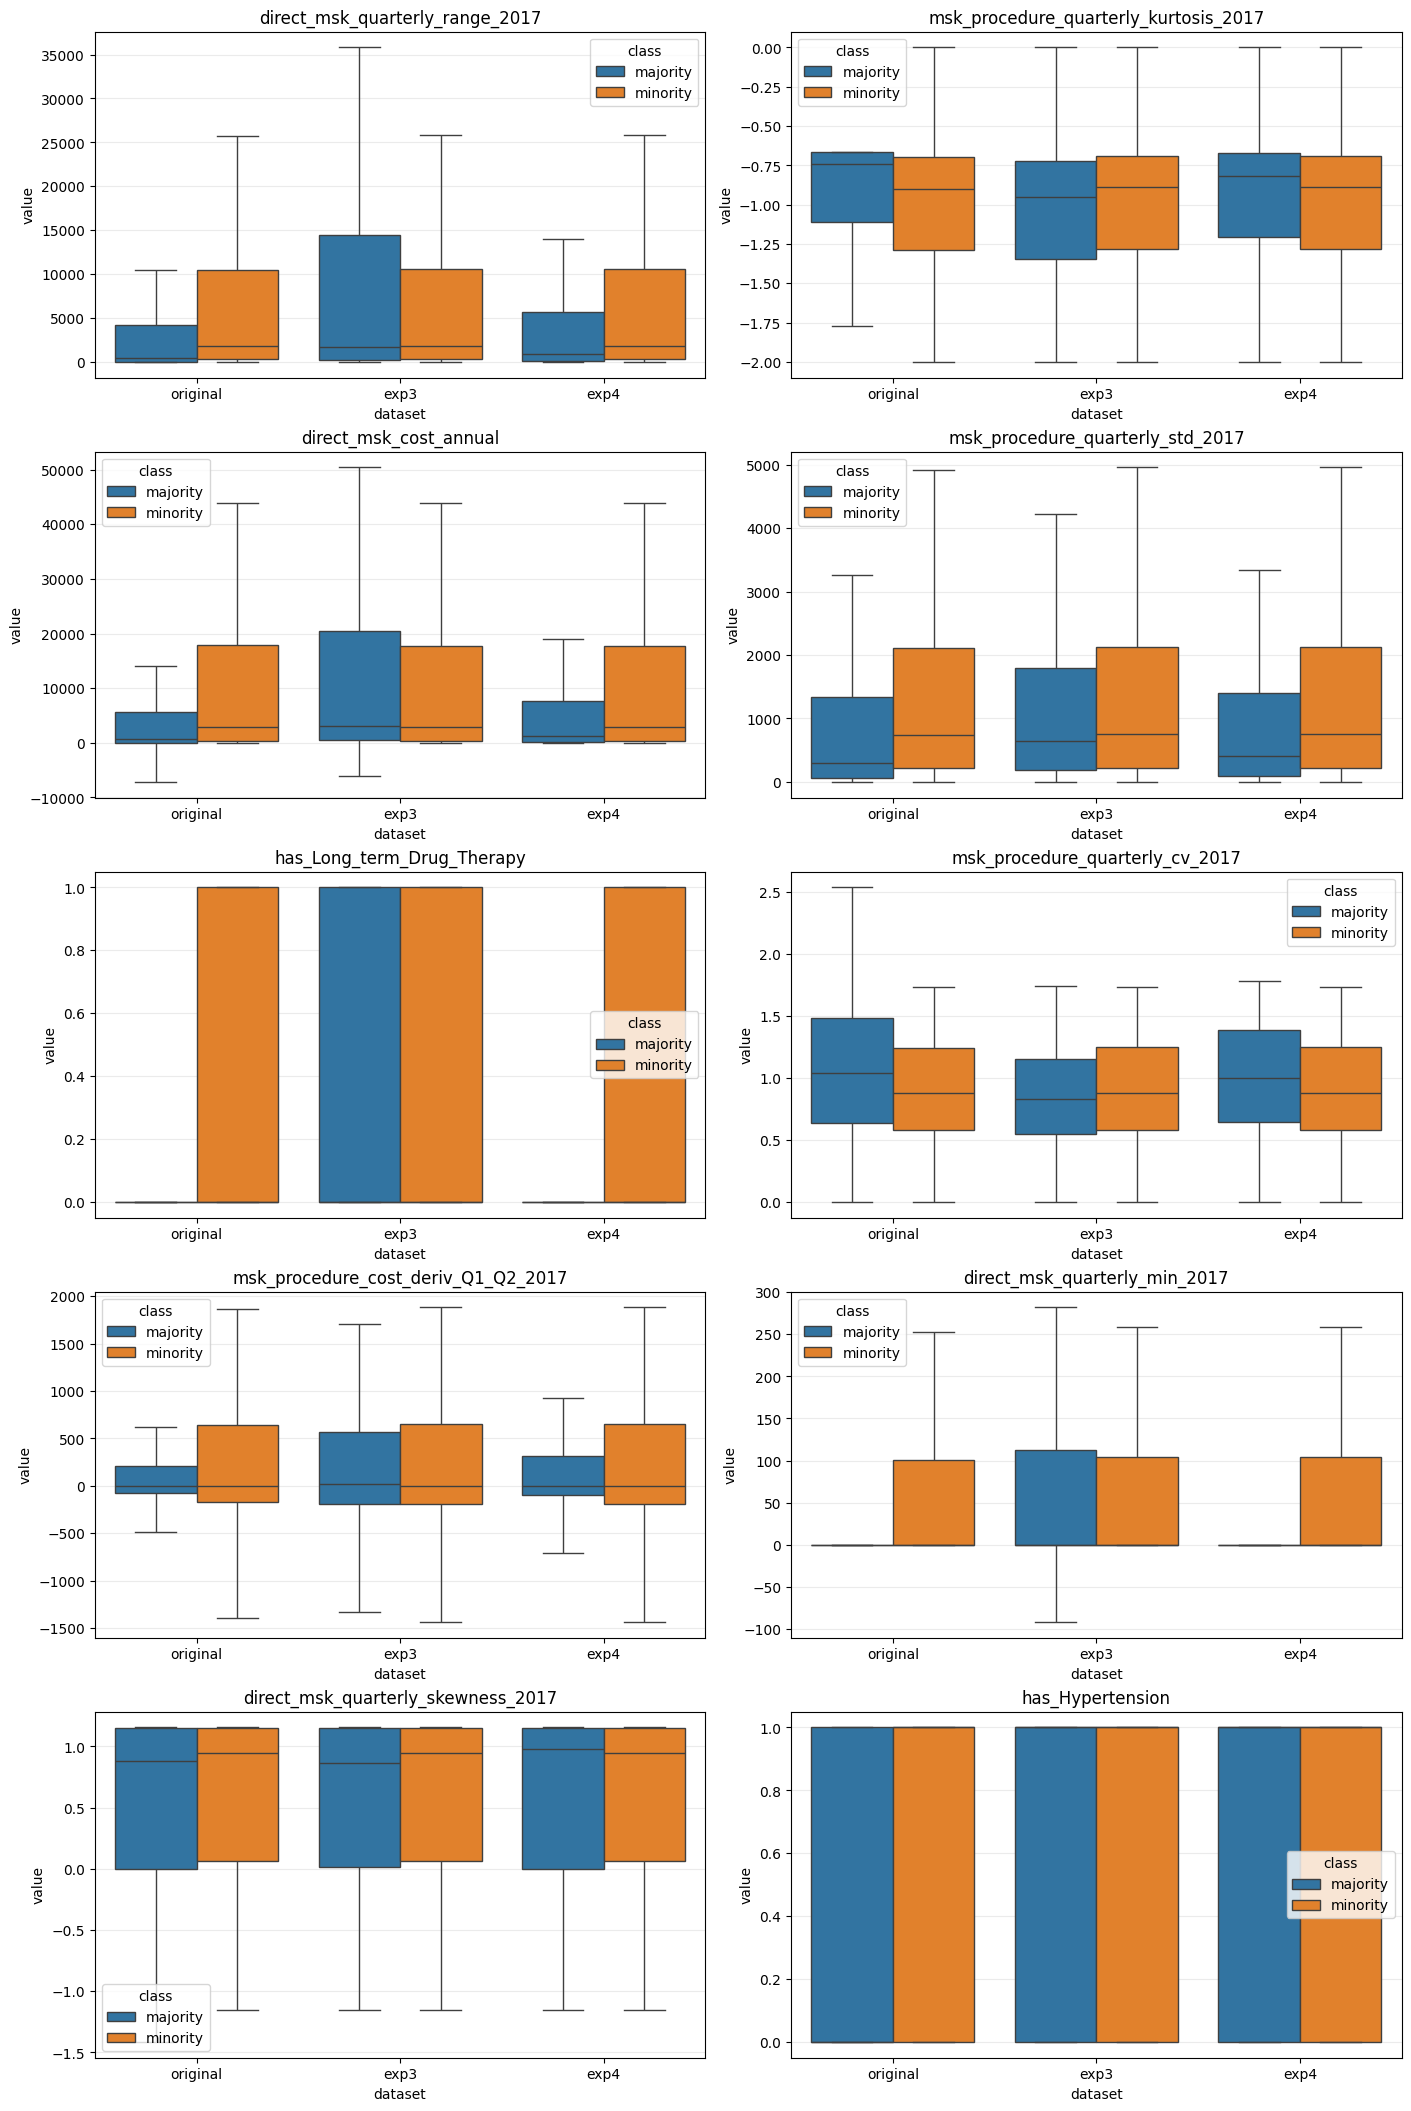

In [46]:
from pathlib import Path

seed = 5
target_col = "top_2_pct_cost_2018"   # change this
base_compare = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_rnd_v_exp4_train_sets")

# original full train data
orig_path = Path("/Users/cat2510/my_projects/msk_analysis/msk_2017_18_no_meds.parquet")  # change this

# sampled train sets
exp3_path = base_compare / f"exp3_mix_s{seed}_train.csv"
exp4_path = base_compare / f"exp4_matched_1N_plus_1N_random_s{seed}_train.csv"

orig_df = pd.read_parquet(orig_path)
exp3_df = pd.read_csv(exp3_path)
exp4_df = pd.read_csv(exp4_path)

print(orig_df.shape, exp3_df.shape, exp4_df.shape)
def prep_long(df, dataset_name, feature_list, target_col):
    cols = [c for c in feature_list if c in df.columns]
    out = df[cols + [target_col]].copy()
    out["dataset"] = dataset_name
    out["class_label"] = np.where(out[target_col] == 1, "minority", "majority")
    return out

plot_df = pd.concat([
    prep_long(orig_df, "original", selected_features, target_col),
    prep_long(exp3_df, "exp3", selected_features, target_col),
    prep_long(exp4_df, "exp4", selected_features, target_col),
], ignore_index=True)

missing = [f for f in selected_features if f not in plot_df.columns]
print("Missing selected features:", missing)
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = [f for f in selected_features if f in plot_df.columns]

n = len(features_to_plot)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for ax, feat in zip(axes, features_to_plot):
    d = plot_df[["dataset", "class_label", feat]].dropna().copy()
    d = d.rename(columns={feat: "value"})

    sns.boxplot(
        data=d,
        x="dataset",
        y="value",
        hue="class_label",
        ax=ax,
        showfliers=False
    )
    ax.set_title(feat)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend_.set_title("class")

for ax in axes[len(features_to_plot):]:
    ax.axis("off")

plt.show()

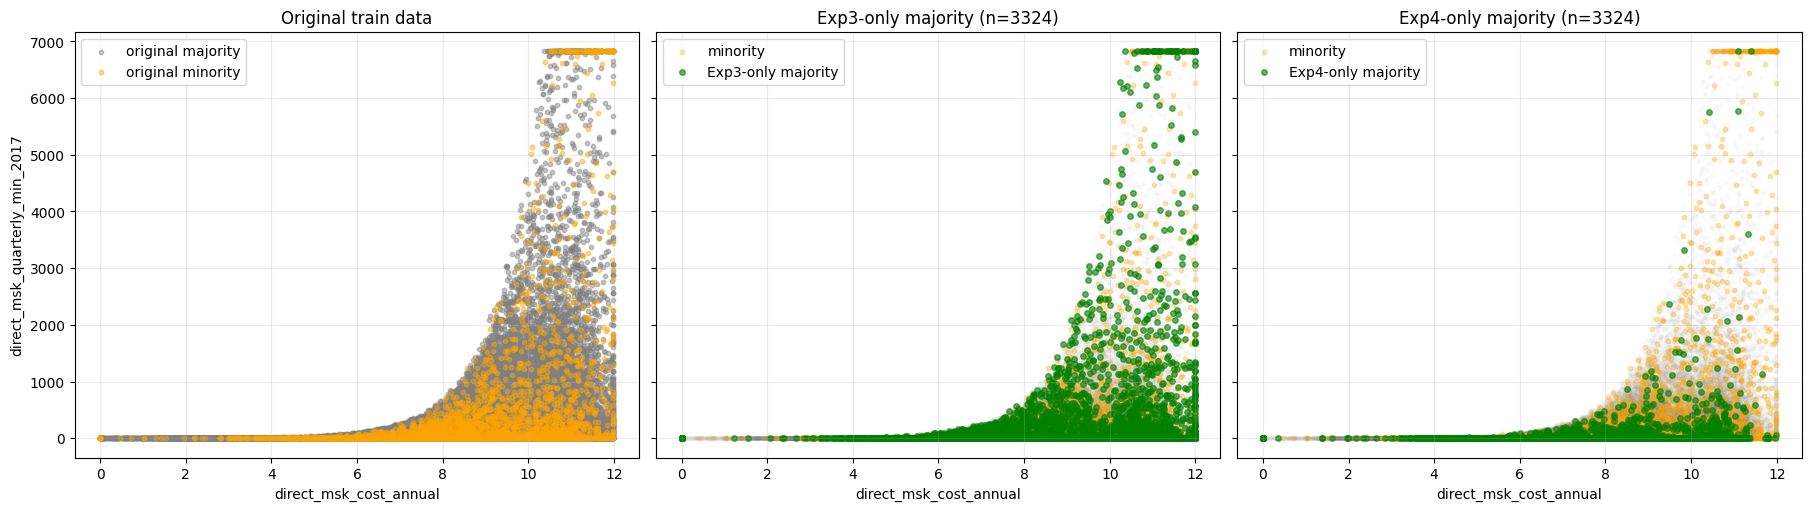

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 5
target_col = "top_2_pct_cost_2018"      # change this
id_col = "ENROLID"        # change this

x_feat = "direct_msk_cost_annual"
y_feat = "direct_msk_quarterly_min_2017"

# sanity checks
for name, df in [("orig", orig_df), ("exp3", exp3_df), ("exp4", exp4_df)]:
    missing = [c for c in [id_col, target_col, x_feat, y_feat] if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

# original copy
viz = orig_df[[id_col, target_col, x_feat, y_feat]].copy()

# selected IDs
exp3_ids = set(exp3_df.loc[exp3_df[target_col] == 0, id_col])   # majority selected in Exp3
exp4_ids = set(exp4_df.loc[exp4_df[target_col] == 0, id_col])   # majority selected in Exp4

viz["is_minority"] = viz[target_col] == 1
exp3_only_ids = exp3_ids - exp4_ids
exp4_only_ids = exp4_ids - exp3_ids

viz["selected_exp3_only"] = viz[id_col].isin(exp3_only_ids)
viz["selected_exp4_only"] = viz[id_col].isin(exp4_only_ids)

def clip_for_plot(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

viz_plot = viz.copy()

viz_plot[x_feat + "_plot"] = clip_for_plot(viz_plot[x_feat], 0.001, 0.999)
viz_plot[y_feat + "_plot"] = clip_for_plot(viz_plot[y_feat], 0.001, 0.999)

# optional log1p transform if nonnegative
if (viz_plot[x_feat + "_plot"] >= 0).all():
    viz_plot[x_feat + "_plot"] = np.log1p(viz_plot[x_feat + "_plot"])

if (viz_plot[y_feat + "_plot"] >= 0).all():
    viz_plot[y_feat + "_plot"] = np.log1p(viz_plot[y_feat + "_plot"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharex=True, sharey=True)

xp = x_feat + "_plot"
yp = y_feat + "_plot"

# Panel 1: original only
ax = axes[0]
maj = viz_plot[~viz_plot["is_minority"]]
mino = viz_plot[viz_plot["is_minority"]]
n_exp3_only = ((~viz_plot["is_minority"]) & (viz_plot["selected_exp3_only"])).sum()
n_exp4_only = ((~viz_plot["is_minority"]) & (viz_plot["selected_exp4_only"])).sum()
ax.scatter(maj[xp], maj[yp], s=10, alpha=0.45, color="gray", label="original majority")
ax.scatter(mino[xp], mino[yp], s=10, alpha=0.45, color="orange", label="original minority")
ax.set_title("Original train data")
ax.set_xlabel(x_feat)
ax.set_ylabel(y_feat)
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 2: Exp3 overlay (no blue cloud)
ax = axes[1]
maj_sel = viz_plot[(~viz_plot["is_minority"]) & (viz_plot["selected_exp3_only"])]
mino = viz_plot[viz_plot["is_minority"]]

# optional faint gray backdrop
ax.scatter(maj[xp], maj[yp], s=6, alpha=0.03, color="gray")
ax.scatter(mino[xp], mino[yp], s=10, alpha=0.30, color="orange", label="minority")
ax.scatter(maj_sel[xp], maj_sel[yp], s=16, alpha=0.60, color="green", label="Exp3-only majority")
ax.set_title(f"Exp3-only majority (n={n_exp3_only})")
ax.set_xlabel(x_feat)
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 3: Exp4 overlay (no blue cloud)
ax = axes[2]
maj_sel = viz_plot[(~viz_plot["is_minority"]) & (viz_plot["selected_exp4_only"])]
mino = viz_plot[viz_plot["is_minority"]]

# optional faint gray backdrop
ax.scatter(maj[xp], maj[yp], s=6, alpha=0.03, color="gray")
ax.scatter(mino[xp], mino[yp], s=10, alpha=0.30, color="orange", label="minority")
ax.scatter(maj_sel[xp], maj_sel[yp], s=16, alpha=0.60, color="green", label="Exp4-only majority")
ax.set_title(f"Exp4-only majority (n={n_exp4_only})")
ax.set_xlabel(x_feat)
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

### Show the test-set population in the same 2D feature space

In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split

# must match the script exactly
PARQUET_PATH = "/Users/cat2510/my_projects/msk_analysis/msk_2017_18_no_meds.parquet"
TARGET_COL = "top_2_pct_cost_2018"
TRAIN_TEST_SEED = 123     # use the exact value from your script

df = pd.read_parquet(PARQUET_PATH)


# ----------------------------
# Train pool (D-N-N + P-N): exclude from holdout to avoid leakage
# ----------------------------
import h5py
distances_dir = "/Users/cat2510/scratch/precomputed_distances_exp6_ablation/"
pn_h5 = os.path.join(distances_dir, "distances_majority_minority_gower.h5")
dnn_dir = os.path.join(distances_dir, f"global_dnn_seed_{TRAIN_TEST_SEED}_gower")
dnn_matrix = os.path.join(dnn_dir, "leaf_global_dnn_matrix.npy")
dnn_enrolids_path = os.path.join(dnn_dir, "leaf_global_dnn_enrolids.npy")
for p in [pn_h5, dnn_enrolids_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Train pool / holdout split require distances: {p}")
ctrl_ids = np.load(dnn_enrolids_path)
with h5py.File(pn_h5, "r") as f:
    case_ids = f["minority_enrolids"][:]
train_ids_set = set(int(e) for e in ctrl_ids) | set(int(e) for e in case_ids)
remainder = df[~df["ENROLID"].isin(train_ids_set)].copy()
print(f"Holdout drawn from {len(remainder):,} rows (train pool {len(train_ids_set):,} excluded)")


val_ids, test_ids = train_test_split(
    remainder["ENROLID"],
    test_size=0.3,
    random_state=TRAIN_TEST_SEED,
    stratify=remainder[TARGET_COL],
)

val_pd = remainder[remainder["ENROLID"].isin(val_ids)].reset_index(drop=True)
test_pd = remainder[remainder["ENROLID"].isin(test_ids)].reset_index(drop=True)

print(test_pd.shape)
print(test_pd[["ENROLID", TARGET_COL]].head())

Holdout drawn from 75,333 rows (train pool 175,777 excluded)
(22600, 99)
    ENROLID  top_2_pct_cost_2018
0  27061501                    0
1  27302101                    0
2  27510802                    0
3  27903905                    0
4  27999701                    0


In [86]:
# check if the ENROLID train_ids_set are distinct from the ENROLID in test_ids
overlap = set(train_ids_set) & set(val_ids)
print(f"Overlap: {len(overlap)}")
print(f"Train set size: {len(train_ids_set)}")
print(f"Test set size: {len(val_ids)}")


Overlap: 0
Train set size: 175777
Test set size: 52733


In [124]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 5
id_col = "ENROLID"
target_col = "top_2_pct_cost_2018"

x_feat = "direct_msk_cost_annual"
y_feat = "msk_procedure_cost_deriv_Q1_Q2_2017"

base = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_rnd_v_exp4_train_sets")

exp3_pred_path = base / f"exp3_mix_s{seed}" / "predictions" / f"oct_predictions_exp3_mix_s{seed}_pruned_d7_mb5_cp1e-05.csv"
exp4_pred_path = base / f"exp4_matched_plus_random_s{seed}" / "predictions" / f"oct_predictions_exp4_matched_plus_random_s{seed}_pruned_d7_mb5_cp1e-05.csv"

exp3_pred = pd.read_csv(exp3_pred_path)
exp4_pred = pd.read_csv(exp4_pred_path)

print(exp3_pred.shape, exp4_pred.shape)
print(exp3_pred.columns.tolist())
def attach_test_ids_and_labels_by_position(pred_df, test_df, id_col="ENROLID", target_col="top_2_pct_cost_2018"):
    if len(pred_df) != len(test_df):
        raise ValueError(f"Length mismatch: pred_df={len(pred_df)}, test_df={len(test_df)}")

    out = pred_df.copy().reset_index(drop=True)
    test_aligned = test_df.reset_index(drop=True)

    out.insert(0, id_col, test_aligned[id_col].values)
    out["y_true"] = test_aligned[target_col].values
    return out
check_cols = [
    "has_Anemia",
    "has_Vitamin_D_Deficiency",
    "has_Dorsopathies",
]

for c in check_cols:
    same_exp3 = np.allclose(
        exp3_pred[c].to_numpy(),
        test_pd[c].reset_index(drop=True).to_numpy(),
        equal_nan=True
    )
    same_exp4 = np.allclose(
        exp4_pred[c].to_numpy(),
        test_pd[c].reset_index(drop=True).to_numpy(),
        equal_nan=True
    )
    print(c, same_exp3, same_exp4)
exp3_pred_aligned = attach_test_ids_and_labels_by_position(exp3_pred, test_pd, id_col="ENROLID", target_col=TARGET_COL)
exp4_pred_aligned = attach_test_ids_and_labels_by_position(exp4_pred, test_pd, id_col="ENROLID", target_col=TARGET_COL)

(22600, 118) (22600, 118)
['direct_msk_cost_pattern_2017_early_heavy', 'direct_msk_cost_pattern_2017_late_heavy', 'direct_msk_cost_stability_2017_moderate', 'direct_msk_cost_stability_2017_stable', 'msk_procedure_cost_pattern_2017_early_heavy', 'msk_procedure_cost_pattern_2017_late_heavy', 'msk_procedure_cost_stability_2017_moderate', 'msk_procedure_cost_stability_2017_stable', 'comorbidity_only_cost_pattern_2017_early_heavy', 'comorbidity_only_cost_pattern_2017_late_heavy', 'comorbidity_only_cost_stability_2017_moderate', 'comorbidity_only_cost_stability_2017_stable', 'AGEGRP_2', 'AGEGRP_3', 'AGEGRP_4', 'AGEGRP_5', 'AGEGRP_6', 'SEX_2', 'REGION_2', 'REGION_3', 'REGION_4', 'REGION_5', 'EESTATU_2', 'EESTATU_3', 'EESTATU_4', 'EESTATU_5', 'EESTATU_6', 'EESTATU_7', 'EESTATU_8', 'EESTATU_9', '2017Q1_direct_msk_cost_3month', '2017Q1_msk_procedure_cost_3month', '2017Q1_comorbidity_only_cost_3month', '2017Q2_direct_msk_cost_3month', '2017Q2_msk_procedure_cost_3month', '2017Q2_comorbidity_only_c

In [125]:
pred_col = "predicted_class_default"

for df in [exp3_pred_aligned, exp4_pred_aligned]:
    df["y_pred"] = df[pred_col].astype(int)
    df["is_misclassified"] = df["y_pred"] != df["y_true"]
    df["is_fn"] = (df["y_true"] == 1) & (df["y_pred"] == 0)
    df["is_fp"] = (df["y_true"] == 0) & (df["y_pred"] == 1)

# outcome comparison table
cmp = exp3_pred_aligned[[id_col, "y_true", "y_pred", "is_misclassified", "is_fn", "is_fp"]].merge(
    exp4_pred_aligned[[id_col, "y_true", "y_pred", "is_misclassified", "is_fn", "is_fp"]],
    on=[id_col, "y_true"],
    suffixes=("_exp3", "_exp4"),
    validate="1:1"
)

# add raw coordinates for plotting
cmp = cmp.merge(
    test_pd[[id_col, x_feat, y_feat]],
    on=id_col,
    how="left",
    validate="1:1"
)

# disagreement flags
cmp["exp3_only_mis"] = cmp["is_misclassified_exp3"] & (~cmp["is_misclassified_exp4"])
cmp["exp4_only_mis"] = cmp["is_misclassified_exp4"] & (~cmp["is_misclassified_exp3"])
cmp["both_mis"] = cmp["is_misclassified_exp3"] & cmp["is_misclassified_exp4"]

cmp["exp3_only_fn"] = cmp["is_fn_exp3"] & (~cmp["is_fn_exp4"])
cmp["exp4_only_fn"] = cmp["is_fn_exp4"] & (~cmp["is_fn_exp3"])

cmp["exp3_only_fp"] = cmp["is_fp_exp3"] & (~cmp["is_fp_exp4"])
cmp["exp4_only_fp"] = cmp["is_fp_exp4"] & (~cmp["is_fp_exp3"])

print(cmp.columns.tolist())
print(cmp[[id_col, x_feat, y_feat]].head())

['ENROLID', 'y_true', 'y_pred_exp3', 'is_misclassified_exp3', 'is_fn_exp3', 'is_fp_exp3', 'y_pred_exp4', 'is_misclassified_exp4', 'is_fn_exp4', 'is_fp_exp4', 'direct_msk_cost_annual', 'msk_procedure_cost_deriv_Q1_Q2_2017', 'exp3_only_mis', 'exp4_only_mis', 'both_mis', 'exp3_only_fn', 'exp4_only_fn', 'exp3_only_fp', 'exp4_only_fp']
    ENROLID  direct_msk_cost_annual  msk_procedure_cost_deriv_Q1_Q2_2017
0  27061501                    0.00                                 0.00
1  27302101                12477.15                                 0.00
2  27510802                24763.27                              2847.22
3  27903905                 5592.99                               291.95
4  27999701                12669.97                               123.27


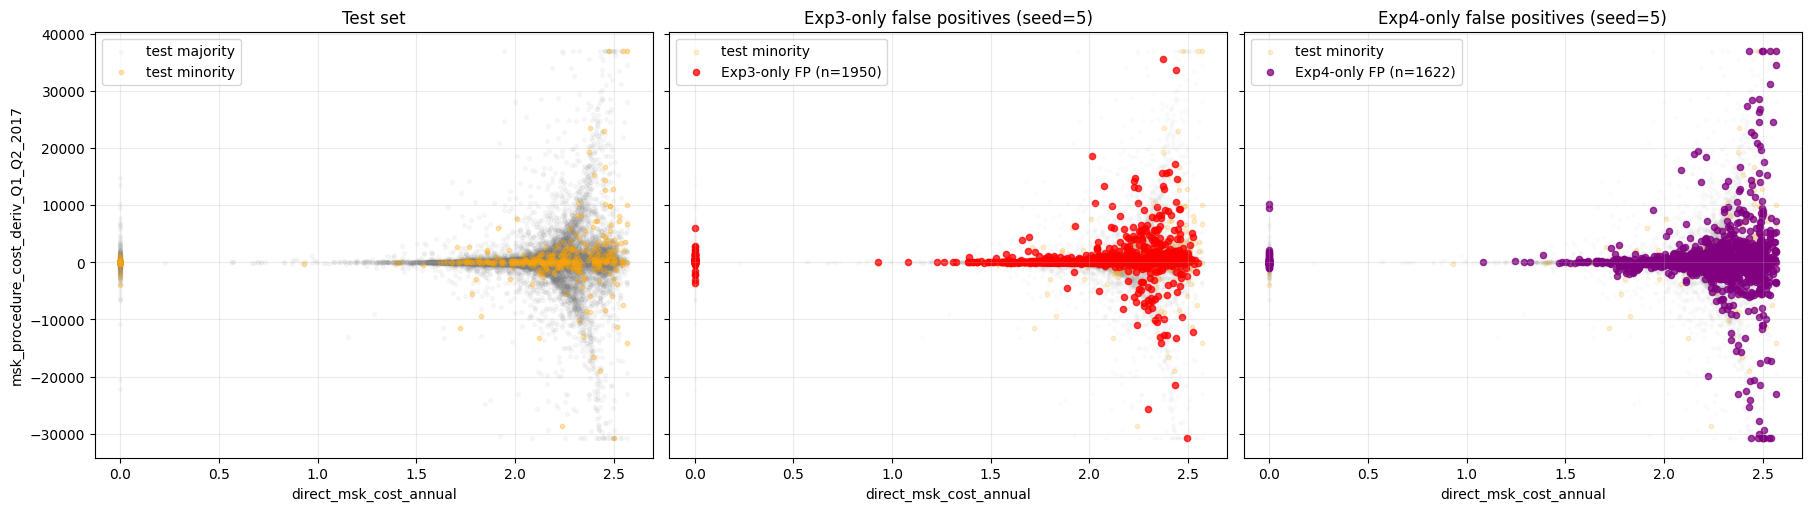

In [126]:
def clip_for_plot(s, lower=0.001, upper=0.999):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

plot_df = cmp.copy()
plot_df[x_feat + "_plot"] = clip_for_plot(plot_df[x_feat], 0.001, 0.999)
plot_df[y_feat + "_plot"] = clip_for_plot(plot_df[y_feat], 0.001, 0.999)

if (plot_df[x_feat + "_plot"] >= 0).all():
    plot_df[x_feat + "_plot"] = np.log1p(plot_df[x_feat + "_plot"])

if (plot_df[y_feat + "_plot"] >= 0).all():
    plot_df[y_feat + "_plot"] = np.log1p(plot_df[y_feat + "_plot"])

if (plot_df[x_feat + "_plot"] >= 0).all():
    plot_df[x_feat + "_plot"] = np.log1p(plot_df[x_feat + "_plot"])

# Only log y if nonnegative; derivatives may not be
if (plot_df[y_feat + "_plot"] >= 0).all():
    plot_df[y_feat + "_plot"] = np.log1p(plot_df[y_feat + "_plot"])

xp = x_feat + "_plot"
yp = y_feat + "_plot"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharex=True, sharey=True)

majority = plot_df[plot_df["y_true"] == 0]
minority = plot_df[plot_df["y_true"] == 1]

# Panel 1: original test set
ax = axes[0]
ax.scatter(majority[xp], majority[yp], s=8, alpha=0.05, color="gray", label="test majority")
ax.scatter(minority[xp], minority[yp], s=10, alpha=0.30, color="orange", label="test minority")
ax.set_title("Test set")
ax.set_xlabel(x_feat)
ax.set_ylabel(y_feat)
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 2: Exp3-only false positives
ax = axes[1]
pts = plot_df[plot_df["exp3_only_fp"]]
ax.scatter(majority[xp], majority[yp], s=6, alpha=0.02, color="gray")
ax.scatter(minority[xp], minority[yp], s=10, alpha=0.18, color="orange", label="test minority")
ax.scatter(pts[xp], pts[yp], s=20, alpha=0.75, color="red", label=f"Exp3-only FP (n={len(pts)})")
ax.set_title(f"Exp3-only false positives (seed={seed})")
ax.set_xlabel(x_feat)
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 3: Exp4-only false positives
ax = axes[2]
pts = plot_df[plot_df["exp4_only_fp"]]
ax.scatter(majority[xp], majority[yp], s=6, alpha=0.02, color="gray")
ax.scatter(minority[xp], minority[yp], s=10, alpha=0.18, color="orange", label="test minority")
ax.scatter(pts[xp], pts[yp], s=20, alpha=0.75, color="purple", label=f"Exp4-only FP (n={len(pts)})")
ax.set_title(f"Exp4-only false positives (seed={seed})")
ax.set_xlabel(x_feat)
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()


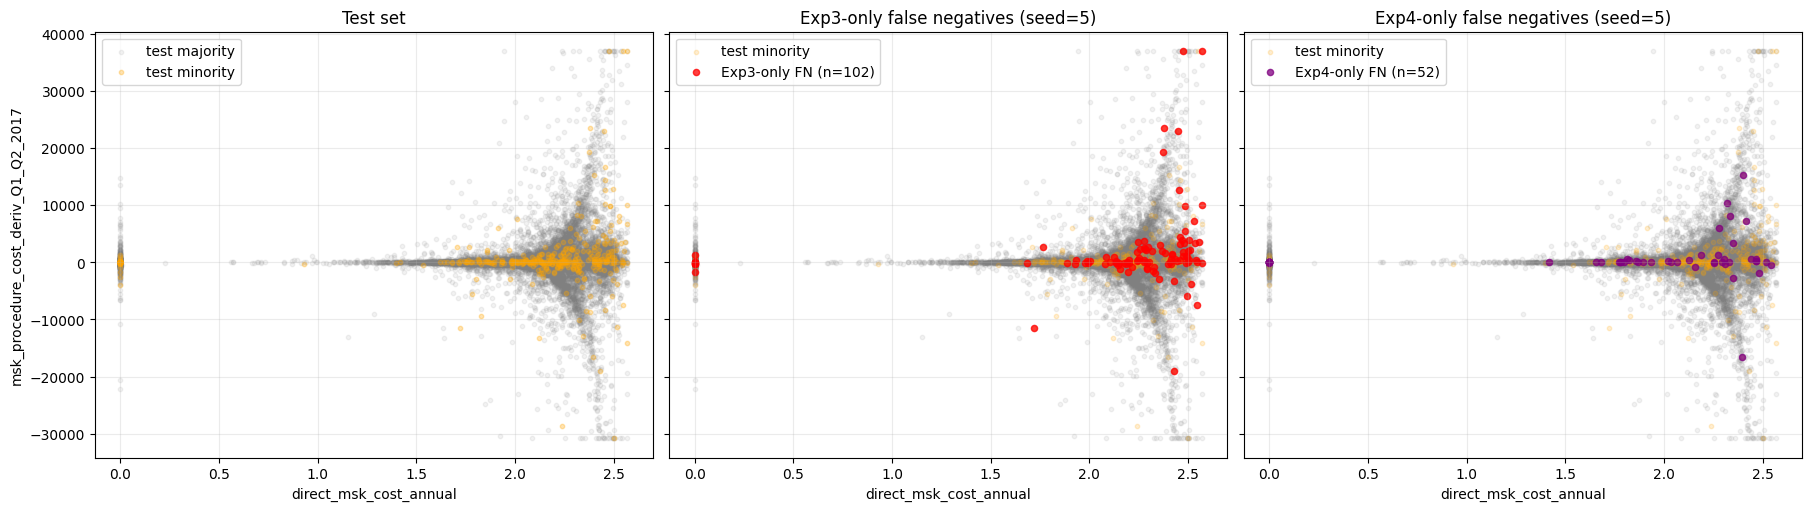

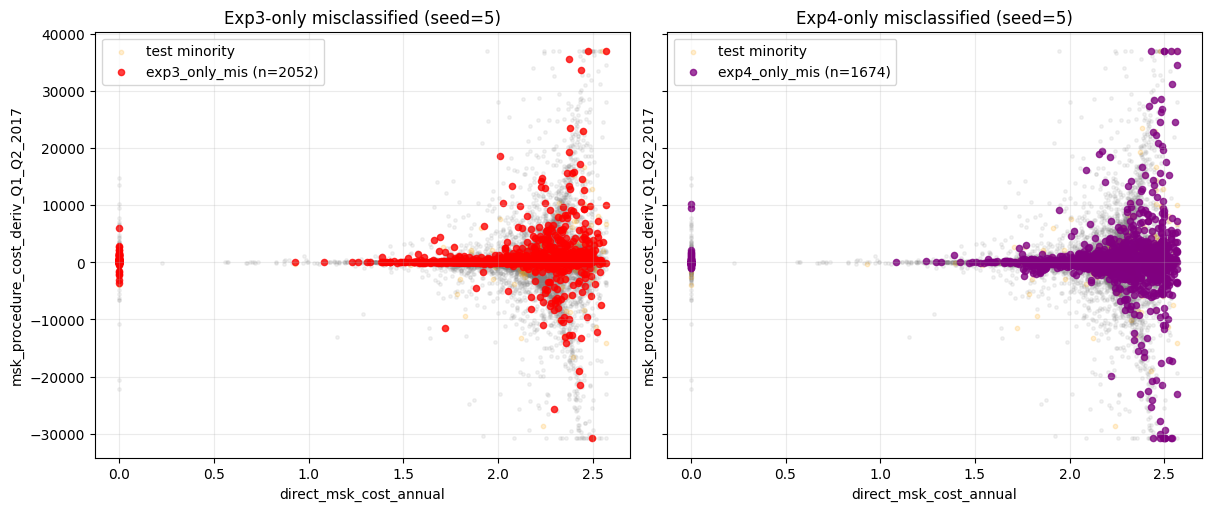

In [127]:
def clip_for_plot(s, lower=0.001, upper=0.999):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

plot_df = cmp.copy()
plot_df[x_feat + "_plot"] = clip_for_plot(plot_df[x_feat], 0.001, 0.999)
plot_df[y_feat + "_plot"] = clip_for_plot(plot_df[y_feat], 0.001, 0.999)

if (plot_df[x_feat + "_plot"] >= 0).all():
    plot_df[x_feat + "_plot"] = np.log1p(plot_df[x_feat + "_plot"])

if (plot_df[y_feat + "_plot"] >= 0).all():
    plot_df[y_feat + "_plot"] = np.log1p(plot_df[y_feat + "_plot"])

if (plot_df[x_feat + "_plot"] >= 0).all():
    plot_df[x_feat + "_plot"] = np.log1p(plot_df[x_feat + "_plot"])

# Only log y if nonnegative; derivatives may not be
if (plot_df[y_feat + "_plot"] >= 0).all():
    plot_df[y_feat + "_plot"] = np.log1p(plot_df[y_feat + "_plot"])

xp = x_feat + "_plot"
yp = y_feat + "_plot"

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True, sharex=True, sharey=True)

majority = plot_df[plot_df["y_true"] == 0]
minority = plot_df[plot_df["y_true"] == 1]

# Panel 1: original test set
ax = axes[0]
ax.scatter(majority[xp], majority[yp], s=10, alpha=0.1, color="gray", label="test majority")
ax.scatter(minority[xp], minority[yp], s=10, alpha=0.30, color="orange", label="test minority")
ax.set_title("Test set")
ax.set_xlabel(x_feat)
ax.set_ylabel(y_feat)
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 2: Exp3-only false negatives
ax = axes[1]
pts = plot_df[plot_df["exp3_only_fn"]]
ax.scatter(majority[xp], majority[yp], s=10, alpha=0.1, color="gray")
ax.scatter(minority[xp], minority[yp], s=10, alpha=0.18, color="orange", label="test minority")
ax.scatter(pts[xp], pts[yp], s=20, alpha=0.75, color="red", label=f"Exp3-only FN (n={len(pts)})")
ax.set_title(f"Exp3-only false negatives (seed={seed})")
ax.set_xlabel(x_feat)
ax.legend()
ax.grid(True, alpha=0.25)

# Panel 3: Exp4-only false negatives
ax = axes[2]
pts = plot_df[plot_df["exp4_only_fn"]]
ax.scatter(majority[xp], majority[yp], s=10, alpha=0.1, color="gray")
ax.scatter(minority[xp], minority[yp], s=10, alpha=0.18, color="orange", label="test minority")
ax.scatter(pts[xp], pts[yp], s=20, alpha=0.75, color="purple", label=f"Exp4-only FN (n={len(pts)})")
ax.set_title(f"Exp4-only false negatives (seed={seed})")
ax.set_xlabel(x_feat)
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, sharex=True, sharey=True)

for ax, col, color, title in [
    (axes[0], "exp3_only_mis", "red", f"Exp3-only misclassified (seed={seed})"),
    (axes[1], "exp4_only_mis", "purple", f"Exp4-only misclassified (seed={seed})"),
]:
    pts = plot_df[plot_df[col]]
    ax.scatter(majority[xp], majority[yp], s=6, alpha=0.1, color="gray")
    ax.scatter(minority[xp], minority[yp], s=10, alpha=0.18, color="orange", label="test minority")
    ax.scatter(pts[xp], pts[yp], s=20, alpha=0.75, color=color, label=f"{col} (n={len(pts)})")
    ax.set_title(title)
    ax.set_xlabel(x_feat)
    ax.set_ylabel(y_feat)
    ax.legend()
    ax.grid(True, alpha=0.25)

plt.show()

## OTHER

In [ ]:
from pathlib import Path

seed = 5
base_compare = Path("/Users/cat2510/my_projects/msk_analysis/compare_oct_cp0_rnd_v_exp4")

# original full train data
orig_path = Path("/Users/cat2510/my_projects/msk_analysis/msk_2017_18_full.parquet")  # change this

# sampled train sets
exp3_path = base_compare / f"exp3_mix_s{seed}" / f"leaf_train_pruned.csv"
exp4_path = base_compare / f"exp4_matched_plus_random_s{seed}" / f"leaf_train_pruned.csv"

orig_df = pd.read_parquet(orig_path)
exp3_df = pd.read_csv(exp3_path)
exp4_df = pd.read_csv(exp4_path)

print(orig_df.shape, exp3_df.shape, exp4_df.shape)

(251110, 115) (39, 4) (60, 4)


In [12]:
import pandas as pd

# load
df = pd.read_csv("../../../scratch/exp_0_to_4_gower/results/experiment_summary.csv")

# keep only exp3 / exp4
sub = df[
    df["experiment"].isin(["exp3", "exp4"]) &
    df["seed"].isin(range(100, 150))
].copy()
sub = df[df["experiment"].isin([ "exp3", "exp4"]) & (df["seed"] < 151)].copy()
sub = df[df["experiment"].isin(["exp3", "exp4"])].copy()

print(sub.shape)
# metrics to summarize
metrics = [
    "auc",
    "pr_auc",
    "best_mcc",
    "recall_mcc",
    "specificity_mcc",
    "optimal_f1",
    "balanced_recall_gmean",
    "balanced_specificity_gmean",
    "recall_at_specificity_0.6",
    "achieved_specificity_0.6",
]

# mean + std summary
summary = (
    sub.groupby(["experiment", "variant"])[metrics]
      .agg(["mean", "std"])
      .round(4)
)

display(summary)

(174, 20)


auc          pr_auc         best_mcc  \
                                        mean     std    mean     std     mean   
experiment variant                                                              
exp3       mix                        0.4985  0.0418  0.0243  0.0040   0.0502   
exp4       matched_1N_plus_1N_random  0.7134  0.0166  0.0643  0.0048   0.1497   

                                             recall_mcc          \
                                         std       mean     std   
experiment variant                                                
exp3       mix                        0.0190     0.1423  0.1384   
exp4       matched_1N_plus_1N_random  0.0072     0.4320  0.0625   

                                     specificity_mcc         optimal_f1  \
                                                mean     std       mean   
experiment variant                                                        
exp3       mix                                0.9336  0.0942     0.0666   
exp4       matched_1N_plus_1N_random          0.8995  0.0268     0.1512   

                                             balanced_recall_gmean          \
                                         std                  mean     std   
experiment variant                                                           
exp3       mix                        0.0160                0.4725  0.1038   
exp4       matched_1N_plus_1N_random  0.0096                0.6133  0.0737   

                                     balanced_specificity_gmean          \
                                                           mean     std   
experiment variant                                                        
exp3       mix                                           0.5841  0.1169   
exp4       matched_1N_plus_1N_random                     0.7397  0.0841   

                                     recall_at_specificity_0.6          \
                                                          mean     std   
experiment variant                                                       
exp3       mix                                          0.3649  0.0843   
exp4       matched_1N_plus_1N_random                    0.6171  0.0858   

                                     achieved_specificity_0.6          
                                                         mean     std  
experiment variant                                                     
exp3       mix                                         0.6885  0.0814  
exp4       matched_1N_plus_1N_random                   0.7321  0.0911